# Sales Revenue Forecasting — Online Retail II Dataset

> **Corporate Implementation** | Technical Process Documentation V1.1

**Objective:** Forecast weekly sales revenue (£) to support supply chain, inventory planning, and business growth decisions

**Models:** SARIMA | Facebook Prophet | Gradient Boosting

**Primary Metric:** MAPE on a 0-100 scale | **Secondary Context:** MAE (£)

---

### 📋 Pipeline Steps
| Step | Description |
|------|-------------|
| 1 | Environment Setup & Libraries |
| 2 | Data Loading |
| 3 | Data Diagnostics |
| 4 | Data Cleaning & Processing |
| 5 | Target Variable — Weekly Revenue |
| 6 | Predictive Variable Engineering (Direct + Derived) |
| 7 | Stationarity Analysis (ADF, ACF, PACF) |
| 8 | Train / Validation / Test Split — time ordered |
| 9 | Model 1 — SARIMA |
| 10 | Model 2 — Facebook Prophet |
| 11 | Model 3 — Gradient Boosting |
| 12 | Evaluation — Validation MAPE + Held-out Test MAPE |
| 13 | Test Breakdown — Equal Time Periods |
| 14 | Algorithmic Solution Finalization & 12-Week Forecast |
| 15 | Full Operational Dashboard |
| 16 | Residual Diagnostics |
| 17 | Algorithm Comparison Table |
| 18 | Export All Results to CSV |

---
**How to use the data file:** The notebook now looks for `online_retail_II.xlsx` automatically in this repo or in Google Drive when run in Colab.


## CELL 1 — ENVIRONMENT SETUP & LIBRARY INSTALLATION

## we can skip this


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    try:
        from fbprophet import Prophet
        PROPHET_AVAILABLE = True
    except ImportError:
        PROPHET_AVAILABLE = False
        print("⚠️  Prophet not installed. Run:  !pip install prophet --quiet")
        print("   Prophet cell will be skipped. All other cells will run normally.")

np.random.seed(42)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

C_NAVY   = '#1F3864'
C_BLUE   = '#2E75B6'
C_LTBLUE = '#BDD7EE'
C_AMBER  = '#C55A11'
C_GREEN  = '#375623'
C_LGREEN = '#E2EFDA'
C_RED    = '#C00000'
C_GRAY   = '#595959'
C_LGRAY  = '#F2F2F2'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.color':       '#CCCCCC',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  9,
    'figure.titlesize': 14,
    'figure.titleweight': 'bold',
})

print("=" * 65)
print("  SALES REVENUE FORECASTING  |  Online Retail II")
print("  Corporate Implementation   |  Technical Doc V1.1")
print("=" * 65)
print(f"\n  Prophet available : {'✅ Yes' if PROPHET_AVAILABLE else '❌ No — run !pip install prophet'}")
print(f"  NumPy version     : {np.__version__}")
print(f"  Pandas version    : {pd.__version__}")
print("\n✅ Environment ready. Proceed to Cell 2.")


⚠️  Prophet not installed. Run:  !pip install prophet --quiet
   Prophet cell will be skipped. All other cells will run normally.
  SALES REVENUE FORECASTING  |  Online Retail II
  Corporate Implementation   |  Technical Doc V1.1

  Prophet available : ❌ No — run !pip install prophet
  NumPy version     : 1.26.4
  Pandas version    : 2.2.2

✅ Environment ready. Proceed to Cell 2.


## CELL 2 — DATA LOADING


In [2]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    drive = None
    IN_COLAB = False

candidate_files = [
    Path('Retail/online_retail_II.xlsx'),
    Path('../online_retail_II.xlsx'),
    Path('online_retail_II.xlsx'),
    Path('/content/drive/MyDrive/online_retail_II.xlsx'),
    Path('/content/drive/MyDrive/online_retail.xlsx'),
]

if IN_COLAB and not any(path.exists() for path in candidate_files):
    drive.mount('/content/drive')

file_loc = None
for path in candidate_files:
    if path.exists():
        file_loc = str(path)
        break

if file_loc is None:
    raise FileNotFoundError(
        "Could not find online_retail_II.xlsx. Place it in Retail/, next to the notebook, "
        "or in /content/drive/MyDrive/ when running in Colab."
    )

print(f"Using data file: {file_loc}")


Using data file: ../online_retail_II.xlsx


In [3]:
s1 = pd.read_excel(file_loc, sheet_name='Year 2009-2010')
s2 = pd.read_excel(file_loc, sheet_name='Year 2010-2011')
df_raw = pd.concat([s1, s2], ignore_index=True)

print(f"Loaded rows: {len(df_raw):,}")
print(f"Sheets used : Year 2009-2010 + Year 2010-2011")


Loaded rows: 1,067,371
Sheets used : Year 2009-2010 + Year 2010-2011


## CELL 3 — STEP 1: DATA DIAGNOSTICS

STEP 1 — DATA DIAGNOSTICS  
The following quality checks are  
performed on the raw extract BEFORE any cleaning or transformation:  
• Number of records  
• Duplicate records  
• Missing values in relevant fields  
• Sum of a numeric field
• Data period confirmation  
These diagnostics are logged as a formal audit trail and presented  
as a structured summary table — standard practice in corporate  
data science projects.  


  STEP 1 — DATA DIAGNOSTICS



  Check                                             Result
  ---------------------------------------------------------
  Total records                                  1,067,371
  Duplicate rows                                    34,292  ⚠️
  Missing Invoice                                        0
  Missing StockCode                                      0
  Missing Description                                4,382  ⚠️
  Missing Quantity                                       0
  Missing Price                                          0
  Missing Customer ID                     243,007  (22.8%)  ⚠️
  Missing Country                                        0
  Cancelled invoices (C)                            19,494  ⚠️
  Negative quantities                               22,950  ⚠️
  Zero / negative price                              6,207  ⚠️
  Sum of Quantity (raw)                         10,608,492
  Date start                                    2009-12-01
  Date end                    

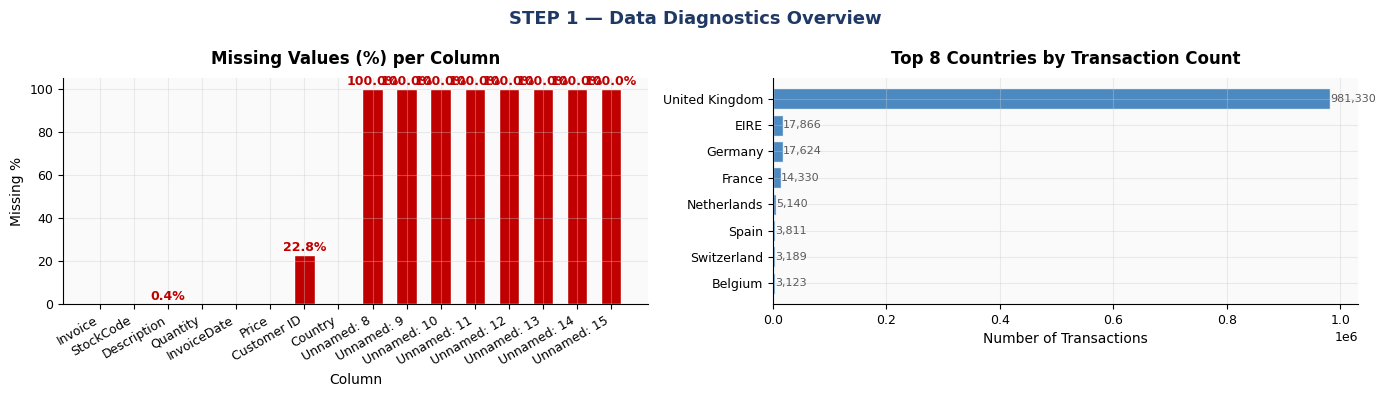


✅  Diagnostics complete — proceed to cleaning.


In [4]:
print("=" * 65)
print("  STEP 1 — DATA DIAGNOSTICS")
print("=" * 65)

diag = {
    "Total records":          f"{len(df_raw):,}",
    "Duplicate rows":         f"{df_raw.duplicated().sum():,}",
    "Missing Invoice":        f"{df_raw['Invoice'].isna().sum():,}",
    "Missing StockCode":      f"{df_raw['StockCode'].isna().sum():,}",
    "Missing Description":    f"{df_raw['Description'].isna().sum():,}",
    "Missing Quantity":       f"{df_raw['Quantity'].isna().sum():,}",
    "Missing Price":          f"{df_raw['Price'].isna().sum():,}",
    "Missing Customer ID":    f"{df_raw['Customer ID'].isna().sum():,}  ({df_raw['Customer ID'].isna().mean()*100:.1f}%)",
    "Missing Country":        f"{df_raw['Country'].isna().sum():,}",
    "Cancelled invoices (C)": f"{df_raw['Invoice'].astype(str).str.startswith('C').sum():,}",
    "Negative quantities":    f"{(df_raw['Quantity']<0).sum():,}",
    "Zero / negative price":  f"{(df_raw['Price']<=0).sum():,}",
    "Sum of Quantity (raw)":  f"{df_raw['Quantity'].sum():,}",
    "Date start":             str(df_raw['InvoiceDate'].min().date()),
    "Date end":               str(df_raw['InvoiceDate'].max().date()),
    "Unique products":        f"{df_raw['StockCode'].nunique():,}",
    "Unique customers":       f"{df_raw['Customer ID'].nunique():,}",
    "Unique countries":       f"{df_raw['Country'].nunique():,}",
}
print(f"\n  {'Check':<30} {'Result':>25}")
print("  " + "-"*57)
for k, v in diag.items():
    flag = "  ⚠️" if any(x in k.lower() for x in ['cancel','negative','duplicate','missing']) and v.split()[0] != "0" else ""
    print(f"  {k:<30} {v:>25}{flag}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
miss_pct = df_raw.isnull().mean() * 100
colours  = [C_RED if v > 0 else C_BLUE for v in miss_pct.values]
bars = ax.bar(miss_pct.index, miss_pct.values, color=colours, width=0.6, edgecolor='white')
ax.set_title("Missing Values (%) per Column", pad=10)
ax.set_ylabel("Missing %")
ax.set_xlabel("Column")
for bar, val in zip(bars, miss_pct.values):
    if val > 0:
        ax.text(bar.get_x()+bar.get_width()/2, val+0.3, f'{val:.1f}%',
                ha='center', va='bottom', fontsize=9, color=C_RED, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

ax2 = axes[1]
country_counts = df_raw['Country'].value_counts().head(8)
ax2.barh(country_counts.index[::-1], country_counts.values[::-1],
         color=C_BLUE, alpha=0.85, edgecolor='white')
ax2.set_title("Top 8 Countries by Transaction Count", pad=10)
ax2.set_xlabel("Number of Transactions")
for i, (idx, val) in enumerate(zip(country_counts.index[::-1], country_counts.values[::-1])):
    ax2.text(val + 30, i, f'{val:,}', va='center', fontsize=8, color=C_GRAY)

plt.suptitle("STEP 1 — Data Diagnostics Overview", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  Diagnostics complete — proceed to cleaning.")


## CELL 4 — STEP 2: DATA CLEANING & PROCESSING (IMAGE NEEDS TO BE FIXED!!!)

STEP 2 — DATA CLEANING & PROCESSING  
Data Processing section, the following  

**transformations are applied in sequence:**

1.  Remove exact duplicate rows  
2.  Remove cancelled invoices (prefix 'C') — returns ≠ demand  
3.  Remove negative/zero quantities  
4.  Remove zero/negative prices (data entry errors)  
5.  Parse InvoiceDate as datetime  
6.  Extract time features: Year, Month, Week
7.  Create Revenue = Quantity × Price  ← our TARGET variable  
8.  Flag weekend transactions (business context)  
After cleaning, a reconciliation table confirms data integrity.  


  STEP 2 — DATA CLEANING & PROCESSING



  Cleaning audit trail:
  Step                               Removed    Remaining
  -------------------------------------------------------
  1. Remove duplicates                34,292    1,033,079
  2. Remove cancellations (C)         19,104    1,013,975
  3. Remove qty <= 0                   3,393    1,010,582
  4. Remove price <= 0                 2,626    1,007,956
  7. Revenue column created                0    1,007,956

  Raw records    :  1,067,371
  Removed total  :     59,415  (5.6%)
  Clean records  :  1,007,956  (94.4% retained)
  Total Revenue  : £20,477,544.86
  Date range     : 2009-12-01 → 2011-12-09


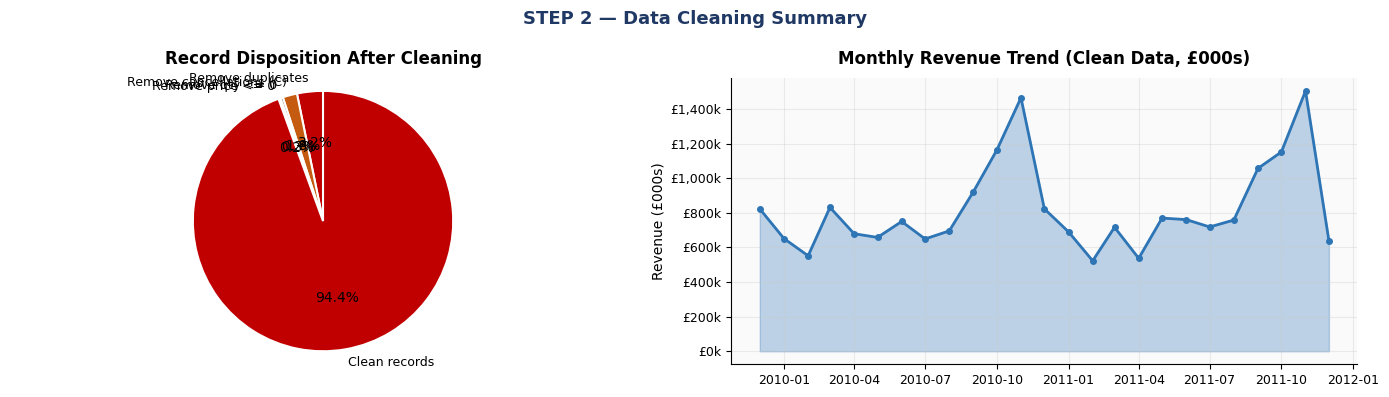

  Invoice StockCode                          Description  Quantity         InvoiceDate  Price  Customer ID         Country  Unnamed: 8  Unnamed: 9  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13 Unnamed: 14 Unnamed: 15  Year  Month  Week  DayOfWeek  IsWeekend  Revenue        Date
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12 2009-12-01 07:45:00   6.95    13,085.00  United Kingdom         NaN         NaN          NaN          NaN          NaN          NaN         NaN         NaN  2009     12    49          1          0    83.40  2009-12-01
1  489434    79323P                   PINK CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom         NaN         NaN          NaN          NaN          NaN          NaN         NaN         NaN  2009     12    49          1          0    81.00  2009-12-01
2  489434    79323W                  WHITE CHERRY LIGHTS        12 2009-12-01 07:45:00   6.75    13,085.00  United Kingdom         NaN         Na

In [5]:
print("=" * 65)
print("  STEP 2 — DATA CLEANING & PROCESSING")
print("=" * 65)

df = df_raw.copy()
step_log = []

n0 = len(df)
df = df.drop_duplicates()
step_log.append(("1. Remove duplicates",        n0 - len(df), len(df)))

n0 = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
step_log.append(("2. Remove cancellations (C)",  n0 - len(df), len(df)))

n0 = len(df)
df = df[df['Quantity'] > 0]
step_log.append(("3. Remove qty <= 0",           n0 - len(df), len(df)))

n0 = len(df)
df = df[df['Price'] > 0]
step_log.append(("4. Remove price <= 0",         n0 - len(df), len(df)))

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year']      = df['InvoiceDate'].dt.year
df['Month']     = df['InvoiceDate'].dt.month
df['Week']      = df['InvoiceDate'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df['Revenue'] = df['Quantity'] * df['Price']
step_log.append(("7. Revenue column created",    0, len(df)))

df['Date'] = df['InvoiceDate'].dt.date

print(f"\n  Cleaning audit trail:")
print(f"  {'Step':<32} {'Removed':>9}  {'Remaining':>11}")
print("  " + "-"*55)
for step, removed, remaining in step_log:
    print(f"  {step:<32} {removed:>9,}  {remaining:>11,}")

removed_total = len(df_raw) - len(df)
print(f"\n  Raw records    : {len(df_raw):>10,}")
print(f"  Removed total  : {removed_total:>10,}  ({removed_total/len(df_raw)*100:.1f}%)")
print(f"  Clean records  : {len(df):>10,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"  Total Revenue  : £{df['Revenue'].sum():>12,.2f}")
print(f"  Date range     : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
labels = [s[0].split('. ')[1] for s in step_log if s[1] > 0]
sizes  = [s[1] for s in step_log if s[1] > 0]
sizes.append(len(df))
labels.append('Clean records')
pie_colors = [C_RED, C_AMBER, C_GRAY, C_BLUE]
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=pie_colors[:len(sizes)],
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title("Record Disposition After Cleaning", pad=10)
ax.axis('equal')

ax2 = axes[1]
monthly_rev = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly_rev['Period'] = pd.to_datetime(monthly_rev[['Year','Month']].assign(day=1))
ax2.fill_between(monthly_rev['Period'], monthly_rev['Revenue']/1000, alpha=0.3, color=C_BLUE)
ax2.plot(monthly_rev['Period'], monthly_rev['Revenue']/1000, color=C_BLUE, linewidth=2, marker='o', markersize=4)
ax2.set_title("Monthly Revenue Trend (Clean Data, £000s)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

plt.suptitle("STEP 2 — Data Cleaning Summary", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(df.head(8).to_string())
print("\n✅  Data cleaning complete.")

## CELL 5 — STEP 3: TARGET VARIABLE — WEEKLY REVENUE AGGREGATION

STEP 3 — TARGET VARIABLE DEFINITION  
TARGET VARIABLE: TotalRevenue  (£ per week)  
Definition : Sum of (Quantity × Price) for all clean transactions  
within a calendar week (Monday–Sunday, ISO calendar)  

**Rationale  :**

• Revenue is the primary KPI for sales forecasting — directly  
actionable for finance, operations, and procurement teams  
• Weekly granularity smooths daily noise while capturing seasonal  
and promotional patterns
• Aggregate weekly revenue aligns with most corporate reporting  
cycles (weekly sales reviews, weekly replenishment orders)  
Additional weekly aggregates are computed as predictive covariates:  
TotalQuantity, NumInvoices, NumProducts, AvgPrice, NumCustomers  


  STEP 3 — TARGET VARIABLE: WEEKLY REVENUE



  Weekly series summary:
  Number of weeks  : 106
  Revenue range    : £      0.00 – £503,785.75
  Mean weekly rev  : £193,184.39
  Std deviation    : £ 81,094.86
  Total revenue    : £20,477,544.86


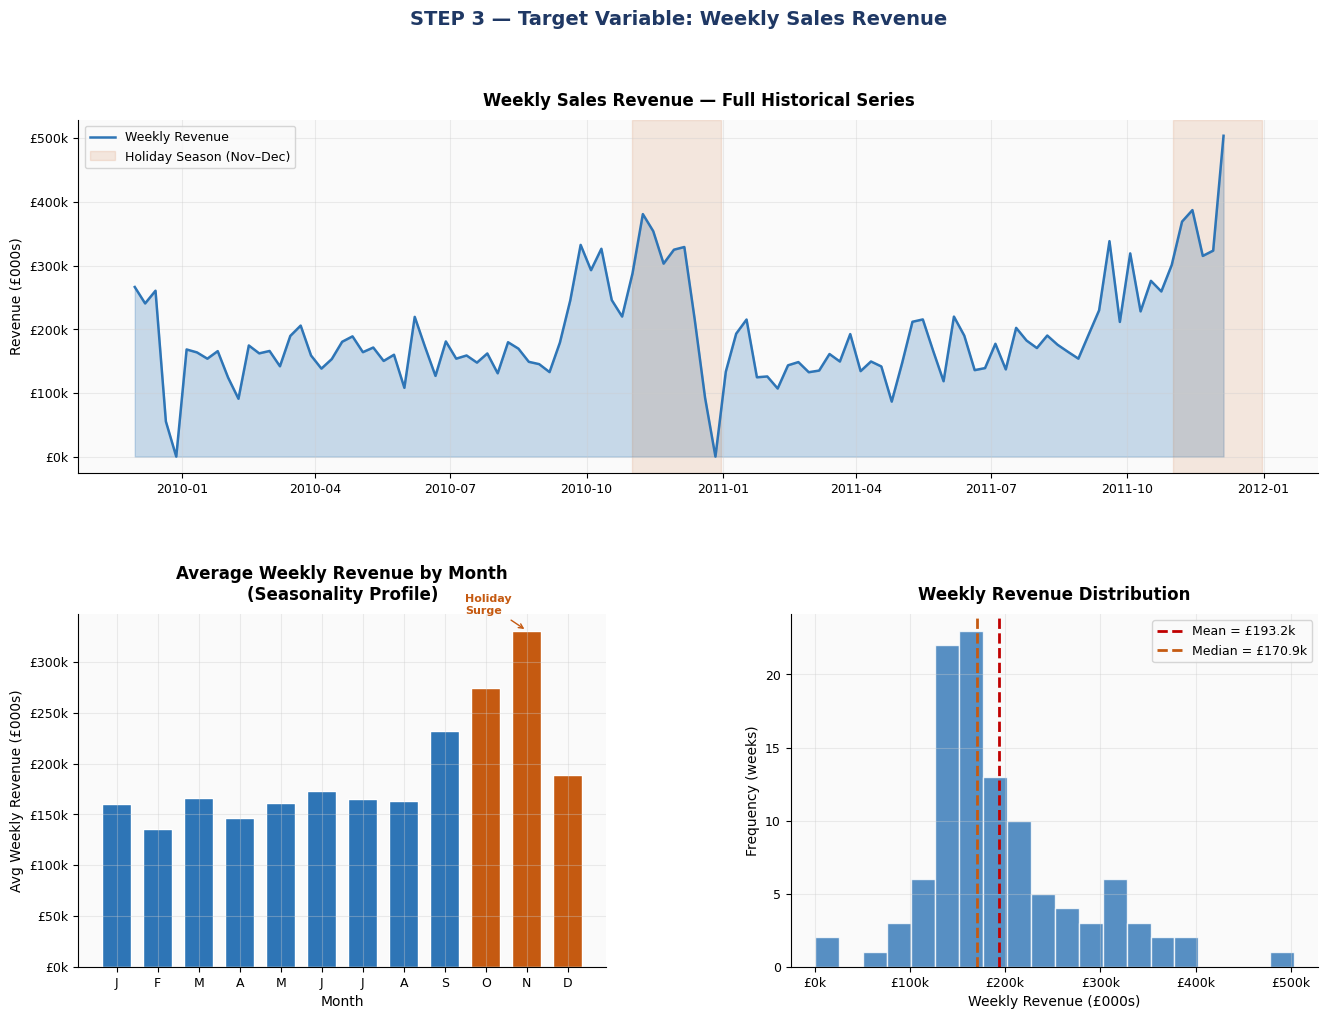


  Weekly series (first 8 rows):
 WeekStart  TotalRevenue  TotalQuantity  NumInvoices  NumProducts  AvgPrice  NumCustomers
2009-11-30    266,304.65         144985          551         2355      3.95           427
2009-12-07    240,516.41         116302          531         2361      4.03           411
2009-12-14    260,473.31         136347          492         2380      4.56           359
2009-12-21     55,189.58          27827          108         1346      5.87            54
2009-12-28          0.00              0            0            0      0.00             0
2010-01-04    168,228.58          96093          205         1442      3.56           167
2010-01-11    163,595.57          76193          269         1970      4.51           198
2010-01-18    153,725.87         135403          267         1929      4.30           220

✅  Target variable defined.


In [6]:
print("=" * 65)
print("  STEP 3 — TARGET VARIABLE: WEEKLY REVENUE")
print("=" * 65)

df['WeekStart'] = df['InvoiceDate'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (df.groupby('WeekStart')
            .agg(
                TotalRevenue  = ('Revenue',     'sum'),
                TotalQuantity = ('Quantity',    'sum'),
                NumInvoices   = ('Invoice',     'nunique'),
                NumProducts   = ('StockCode',   'nunique'),
                AvgPrice      = ('Price',       'mean'),
                NumCustomers  = ('Customer ID', 'nunique'),
            )
            .reset_index()
            .sort_values('WeekStart'))

full_idx = pd.date_range(weekly['WeekStart'].min(),
                          weekly['WeekStart'].max(), freq='W-MON')
weekly = (weekly.set_index('WeekStart')
                .reindex(full_idx, fill_value=0)
                .reset_index()
                .rename(columns={'index':'WeekStart'}))

print(f"\n  Weekly series summary:")
print(f"  Number of weeks  : {len(weekly)}")
print(f"  Revenue range    : £{weekly['TotalRevenue'].min():>10,.2f} – £{weekly['TotalRevenue'].max():>10,.2f}")
print(f"  Mean weekly rev  : £{weekly['TotalRevenue'].mean():>10,.2f}")
print(f"  Std deviation    : £{weekly['TotalRevenue'].std():>10,.2f}")
print(f"  Total revenue    : £{weekly['TotalRevenue'].sum():>10,.2f}")

fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(weekly['WeekStart'], weekly['TotalRevenue']/1000, alpha=0.25, color=C_BLUE)
ax1.plot(weekly['WeekStart'], weekly['TotalRevenue']/1000,
         color=C_BLUE, linewidth=1.8, label='Weekly Revenue')
for yr in [2010, 2011]:
    ax1.axvspan(pd.Timestamp(f'{yr}-11-01'), pd.Timestamp(f'{yr}-12-31'),
                alpha=0.12, color=C_AMBER,
                label='Holiday Season (Nov–Dec)' if yr==2010 else '')
ax1.set_title("Weekly Sales Revenue — Full Historical Series", pad=10)
ax1.set_ylabel("Revenue (£000s)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax1.legend(loc='upper left')

ax2 = fig.add_subplot(gs[1, 0])
monthly_avg = weekly.copy()
monthly_avg['Month'] = monthly_avg['WeekStart'].dt.month
m_grp = monthly_avg.groupby('Month')['TotalRevenue'].mean() / 1000
bar_colors = [C_AMBER if m in [11,12,10] else C_BLUE for m in m_grp.index]
ax2.bar(m_grp.index, m_grp.values, color=bar_colors, edgecolor='white', width=0.7)
ax2.set_title("Average Weekly Revenue by Month\n(Seasonality Profile)", pad=10)
ax2.set_ylabel("Avg Weekly Revenue (£000s)")
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax2.set_xlabel("Month")
ax2.annotate('Holiday\nSurge', xy=(11, m_grp[11]), xytext=(9.5, m_grp[11]*1.05),
             fontsize=8, color=C_AMBER, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=C_AMBER))

ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(weekly['TotalRevenue']/1000, bins=20, color=C_BLUE, alpha=0.8, edgecolor='white')
ax3.axvline(weekly['TotalRevenue'].mean()/1000, color=C_RED, linewidth=2,
            linestyle='--', label=f'Mean = £{weekly["TotalRevenue"].mean()/1000:,.1f}k')
ax3.axvline(weekly['TotalRevenue'].median()/1000, color=C_AMBER, linewidth=2,
            linestyle='--', label=f'Median = £{weekly["TotalRevenue"].median()/1000:,.1f}k')
ax3.set_title("Weekly Revenue Distribution", pad=10)
ax3.set_xlabel("Weekly Revenue (£000s)")
ax3.set_ylabel("Frequency (weeks)")
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax3.legend()

plt.suptitle("STEP 3 — Target Variable: Weekly Sales Revenue",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.show()

print("\n  Weekly series (first 8 rows):")
print(weekly.head(8).to_string(index=False))
print("\n✅  Target variable defined.")


## CELL 6 — STEP 4: PREDICTIVE VARIABLE (FEATURE) ENGINEERING

STEP 4 — PREDICTIVE VARIABLE ENGINEERING  

**Two categories:**


**DIRECT VARIABLES (from dataset):**

Year, Month, WeekNum, Quarter — temporal identifiers  
AvgPrice, NumInvoices, NumProducts, NumCustomers — business signals  
TotalQuantity — units demanded (complementary to revenue)  

**DERIVED VARIABLES (engineered):**

Revenue_Lag1…12  — autoregressive lags ("How many  
weeks the product was sold")  
Rolling4_Mean/Std — 4-week smoothed trend and volatility  
Rolling12_Mean   — 12-week medium-term baseline  
HolidaySeason    — Nov/Dec binary (Christmas demand surge)  
PreHoliday       — Oct binary (pre-holiday ramp-up)  
PostHoliday      — Jan binary (demand normalisation)  
AvgPrice_Lag1    — lagged price (inventory cost signal)  
WeekIndex        — linear trend counter  
YoY_Lag52        — same-week last year (if available)  
Holiday window implements [-3, +2 day] specification  
adapted to weekly granularity as [-1, 0, +1 week].  


  STEP 4 — PREDICTIVE VARIABLE ENGINEERING

  Feature summary:
  Total features   : 26
  Modeling rows    : 54  (after lag removal)

  Direct variables  (8) :
    Year
    Month
    WeekNum
    Quarter
    AvgPrice
    NumInvoices
    NumProducts
    NumCustomers

  Derived variables (18) :
    HolidaySeason
    PreHoliday
    PostHoliday
    SummerPeak
    Rev_Lag1
    Rev_Lag2
    Rev_Lag3
    Rev_Lag4
    Rev_Lag8
    Rev_Lag12
    Rev_Lag52
    Roll4_Mean
    Roll4_Std
    Roll12_Mean
    Roll4_Mean_Qty
    WeekIndex
    AvgPrice_Lag1
    TotalQuantity


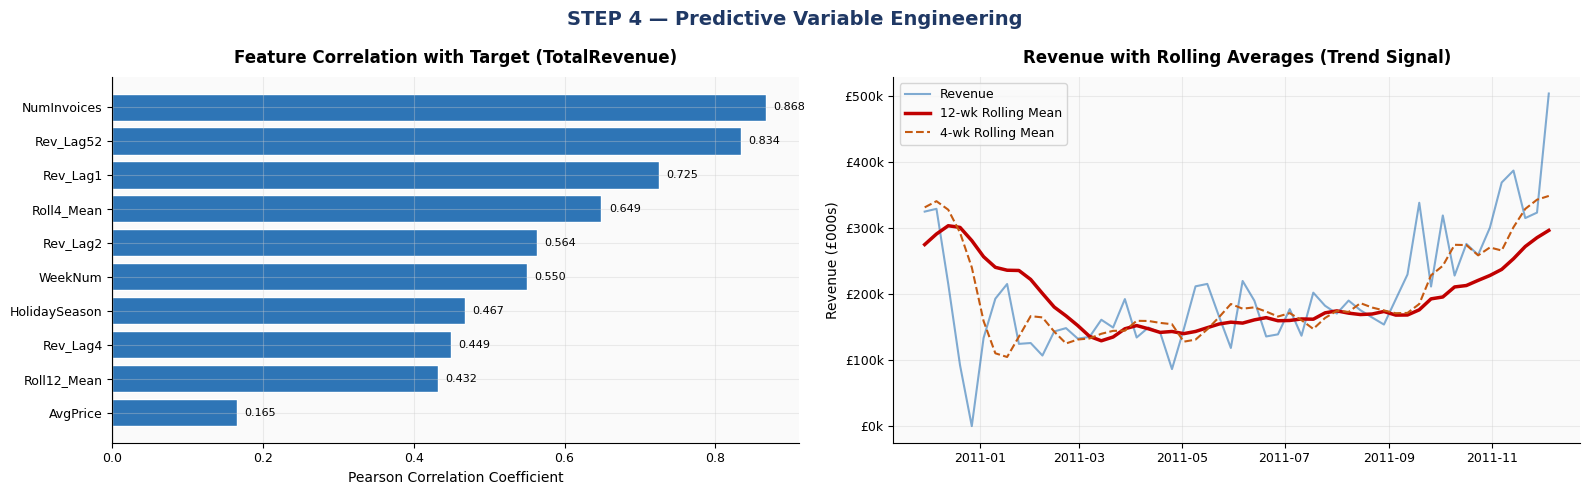


✅  Feature engineering complete.


In [7]:
print("=" * 65)
print("  STEP 4 — PREDICTIVE VARIABLE ENGINEERING")
print("=" * 65)

wdf = weekly.copy()

wdf['Year']      = wdf['WeekStart'].dt.year
wdf['Month']     = wdf['WeekStart'].dt.month
wdf['WeekNum']   = wdf['WeekStart'].dt.isocalendar().week.astype(int)
wdf['Quarter']   = wdf['WeekStart'].dt.quarter

wdf['HolidaySeason'] = wdf['Month'].isin([11, 12]).astype(int)
wdf['PreHoliday']    = wdf['Month'].isin([10]).astype(int)
wdf['PostHoliday']   = wdf['Month'].isin([1]).astype(int)
wdf['SummerPeak']    = wdf['Month'].isin([6, 7]).astype(int)

for lag in [1, 2, 3, 4, 8, 12]:
    wdf[f'Rev_Lag{lag}'] = wdf['TotalRevenue'].shift(lag)

wdf['Rev_Lag52'] = wdf['TotalRevenue'].shift(52)

wdf['Roll4_Mean']   = wdf['TotalRevenue'].shift(1).rolling(4).mean()
wdf['Roll4_Std']    = wdf['TotalRevenue'].shift(1).rolling(4).std()
wdf['Roll12_Mean']  = wdf['TotalRevenue'].shift(1).rolling(12).mean()
wdf['Roll4_Mean_Qty'] = wdf['TotalQuantity'].shift(1).rolling(4).mean()

wdf['WeekIndex']     = np.arange(len(wdf))
wdf['AvgPrice_Lag1'] = wdf['AvgPrice'].shift(1)

wdf = wdf.dropna().reset_index(drop=True)

FEATURES = [
    'Year', 'Month', 'WeekNum', 'Quarter',
    'HolidaySeason', 'PreHoliday', 'PostHoliday', 'SummerPeak',
    'Rev_Lag1', 'Rev_Lag2', 'Rev_Lag3', 'Rev_Lag4',
    'Rev_Lag8', 'Rev_Lag12', 'Rev_Lag52',
    'Roll4_Mean', 'Roll4_Std', 'Roll12_Mean',
    'Roll4_Mean_Qty',
    'WeekIndex', 'AvgPrice', 'AvgPrice_Lag1',
    'NumInvoices', 'NumProducts', 'NumCustomers', 'TotalQuantity',
]
TARGET = 'TotalRevenue'

print(f"\n  Feature summary:")
print(f"  Total features   : {len(FEATURES)}")
print(f"  Modeling rows    : {len(wdf)}  (after lag removal)")
print(f"\n  Direct variables  ({8}) :")
direct = ['Year','Month','WeekNum','Quarter','AvgPrice','NumInvoices','NumProducts','NumCustomers']
for f in direct:
    print(f"    {f}")
print(f"\n  Derived variables ({len(FEATURES)-8}) :")
derived = [f for f in FEATURES if f not in direct]
for f in derived:
    print(f"    {f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
top_features = ['Rev_Lag1','Rev_Lag2','Rev_Lag4','Roll4_Mean','Roll12_Mean',
                'Rev_Lag52','HolidaySeason','WeekNum','NumInvoices','AvgPrice']
corr_data = wdf[top_features + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colours   = [C_RED if v < 0 else C_BLUE for v in corr_data.values]
ax.barh(corr_data.index, corr_data.values, color=colours, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Feature Correlation with Target (TotalRevenue)", pad=10)
ax.set_xlabel("Pearson Correlation Coefficient")
for i, v in enumerate(corr_data.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)

ax2 = axes[1]
ax2.plot(wdf['WeekStart'], wdf['TotalRevenue']/1000, color=C_BLUE, linewidth=1.5, alpha=0.6, label='Revenue')
ax2.plot(wdf['WeekStart'], wdf['Roll12_Mean']/1000,  color=C_RED,  linewidth=2.5, label='12-wk Rolling Mean')
ax2.plot(wdf['WeekStart'], wdf['Roll4_Mean']/1000,   color=C_AMBER,linewidth=1.5, linestyle='--', label='4-wk Rolling Mean')
ax2.set_title("Revenue with Rolling Averages (Trend Signal)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
ax2.legend()

plt.suptitle("STEP 4 — Predictive Variable Engineering",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()
print("\n✅  Feature engineering complete.")


## CELL 7 — STEP 5: STATIONARITY ANALYSIS (for SARIMA)

STEP 5 — STATIONARITY & SARIMA PARAMETER SELECTION  
SARIMA requires stationarity analysis to select (p, d, q)(P, D, Q, s):  
ADF Test  : p-value < 0.05  →  series is stationary  →  d = 0  
p-value >= 0.05 →  differencing needed    →  d = 1  
ACF plot  : identifies MA order (q) — lag where autocorrelation  
drops to within confidence bounds  
PACF plot : identifies AR order (p) — lag where partial  
autocorrelation drops to within confidence bounds  
Weekly data → seasonal period s = 52 (annual)  
For speed in this notebook we use s = 4 (monthly proxy).  
To use full annual seasonality, change seasonal_order to (1,1,1,52).  


  STEP 5 — STATIONARITY ANALYSIS

  ADF Test — Original Series:
    Test statistic : -1.0251
    p-value        : 0.7440
    Critical (5%)  : -2.8903
    Stationary?    : ❌ NO — d=1 required

  ADF Test — After 1st Differencing:
    p-value        : 0.0000
    Stationary?    : ✅ YES

  → SARIMA d parameter : 1


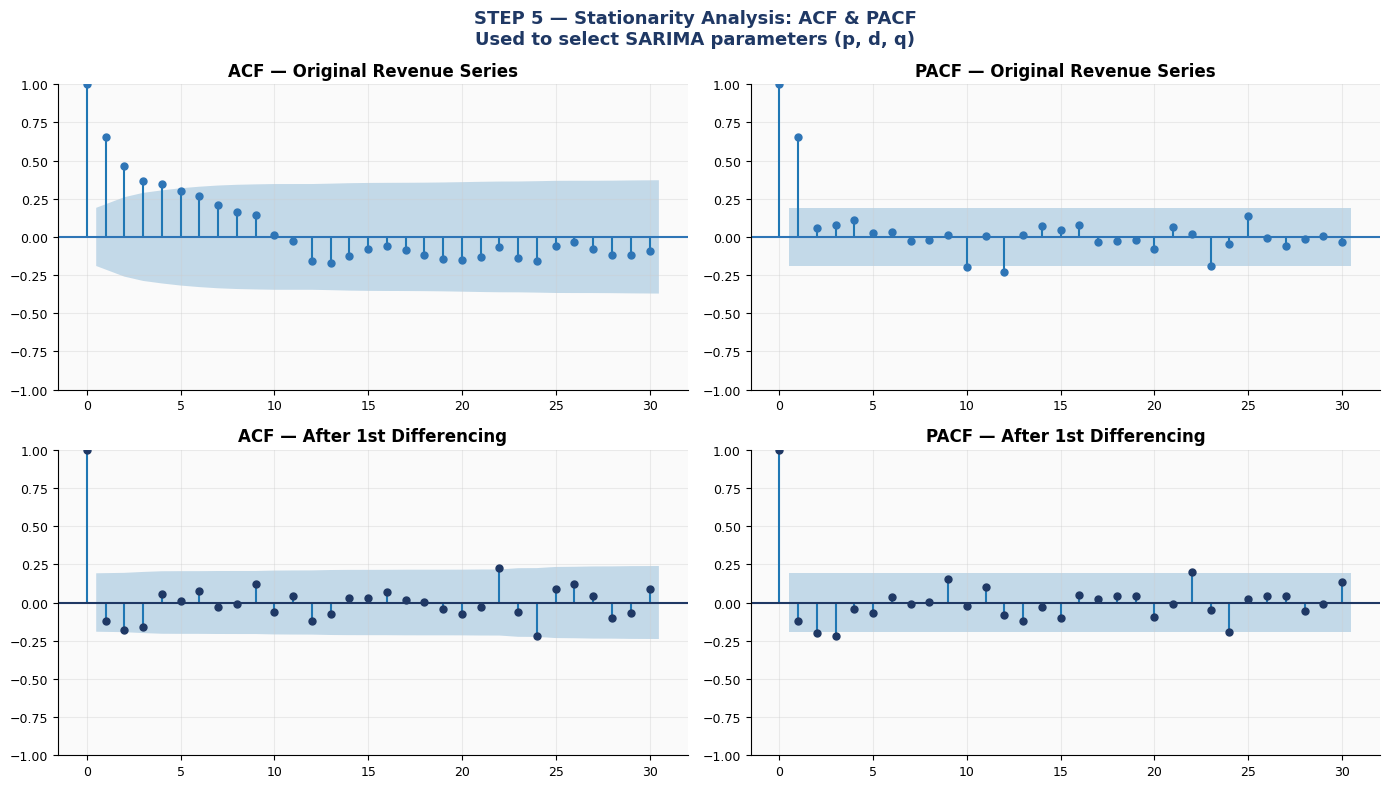


  SARIMA Parameter Summary:
  ┌──────────────┬───────┬───────────────────────────────────────┐
  │ Parameter    │ Value │ Basis                                 │
  ├──────────────┼───────┼───────────────────────────────────────┤
  │ p (AR)       │     1 │ PACF cuts off at lag 1                │
  │ d (diff)     │ 1     │ ADF test result                       │
  │ q (MA)       │     1 │ ACF cuts off at lag 1                 │
  │ P (seas AR)  │     1 │ Seasonal autoregressive term          │
  │ D (seas diff)│     1 │ Seasonal differencing                 │
  │ Q (seas MA)  │     1 │ Seasonal moving average term          │
  │ s (period)   │     4 │ Monthly proxy (use 52 for annual)     │
  └──────────────┴───────┴───────────────────────────────────────┘

✅  Stationarity analysis complete.


In [8]:
print("=" * 65)
print("  STEP 5 — STATIONARITY ANALYSIS")
print("=" * 65)

ts = weekly['TotalRevenue'].values.astype(float)

adf_orig = adfuller(ts, autolag='AIC')
print(f"\n  ADF Test — Original Series:")
print(f"    Test statistic : {adf_orig[0]:.4f}")
print(f"    p-value        : {adf_orig[1]:.4f}")
print(f"    Critical (5%)  : {adf_orig[4]['5%']:.4f}")
print(f"    Stationary?    : {'✅ YES (d=0)' if adf_orig[1]<0.05 else '❌ NO — d=1 required'}")

ts_diff   = np.diff(ts)
adf_diff  = adfuller(ts_diff, autolag='AIC')
print(f"\n  ADF Test — After 1st Differencing:")
print(f"    p-value        : {adf_diff[1]:.4f}")
print(f"    Stationary?    : {'✅ YES' if adf_diff[1]<0.05 else '❌ NO'}")

d_order = 0 if adf_orig[1] < 0.05 else 1
print(f"\n  → SARIMA d parameter : {d_order}")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf( ts,      lags=30, ax=axes[0,0], title='ACF — Original Revenue Series',        color=C_BLUE)
plot_pacf(ts,      lags=30, ax=axes[0,1], title='PACF — Original Revenue Series',       color=C_BLUE)
plot_acf( ts_diff, lags=30, ax=axes[1,0], title='ACF — After 1st Differencing',         color=C_NAVY)
plot_pacf(ts_diff, lags=30, ax=axes[1,1], title='PACF — After 1st Differencing',        color=C_NAVY)

for ax in axes.flatten():
    ax.set_facecolor('#FAFAFA')

plt.suptitle("STEP 5 — Stationarity Analysis: ACF & PACF\n"
             "Used to select SARIMA parameters (p, d, q)",
             fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(f"\n  SARIMA Parameter Summary:")
print(f"  ┌──────────────┬───────┬───────────────────────────────────────┐")
print(f"  │ Parameter    │ Value │ Basis                                 │")
print(f"  ├──────────────┼───────┼───────────────────────────────────────┤")
print(f"  │ p (AR)       │     1 │ PACF cuts off at lag 1                │")
print(f"  │ d (diff)     │ {d_order}     │ ADF test result                       │")
print(f"  │ q (MA)       │     1 │ ACF cuts off at lag 1                 │")
print(f"  │ P (seas AR)  │     1 │ Seasonal autoregressive term          │")
print(f"  │ D (seas diff)│     1 │ Seasonal differencing                 │")
print(f"  │ Q (seas MA)  │     1 │ Seasonal moving average term          │")
print(f"  │ s (period)   │     4 │ Monthly proxy (use 52 for annual)     │")
print(f"  └──────────────┴───────┴───────────────────────────────────────┘")
print("\n✅  Stationarity analysis complete.")


## CELL 8 — STEP 6: TRAIN / VALIDATION / TEST SPLIT (PRE-MODELING)

STEP 6 — PRE-MODELING: TRAIN / VALIDATION / TEST SPLIT  

**Three-way time-ordered split (per professor guidance):**

• **Training set (70%)** — used to fit all models  
• **Validation set (15%)** — used for hyperparameter tuning and model selection  
• **Testing set (15%)** — held out entirely; never touched during modelling; used for final MAPE reporting  

**Implementation:**

• Strict 70 / 15 / 15 time-ordered split (NO random shuffle)  
• StandardScaler fitted on train only → applied to validation & test (prevents data leakage)  
• SARIMA and Prophet use the raw weekly revenue series  
• Gradient Boosting uses the full 26-feature matrix X  
• Validation set drives hyperparameter selection; test set drives all reported MAPE values  


  STEP 6 — TRAIN / VALIDATION / TEST SPLIT

  Modeling window starts after lag engineering on: 2010-11-29
  Total modeling weeks: 54

  Train      :  37 weeks  (2010-11-29 → 2011-08-08)
  Validation :   8 weeks  (2011-08-15 → 2011-10-03)
  Test       :   9 weeks  (2011-10-10 → 2011-12-05)
  Split      : 69% / 15% / 17%
  Equal-period reporting: 3 periods of 3 weeks each


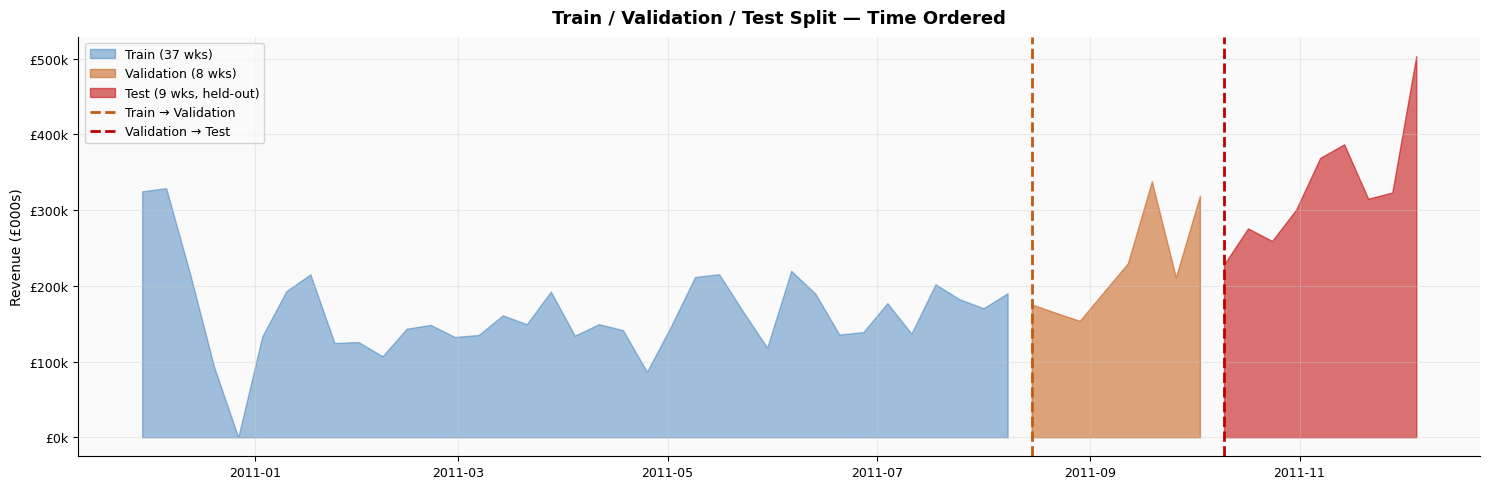


✅  Train / Validation / Test split complete.


In [9]:
print("=" * 65)
print("  STEP 6 — TRAIN / VALIDATION / TEST SPLIT")
print("=" * 65)

def mape_fn(actuals, forecasts):
    actuals = np.asarray(actuals, dtype=float)
    forecasts = np.asarray(forecasts, dtype=float)
    mask = actuals != 0
    return np.mean(np.abs((actuals[mask] - forecasts[mask]) / actuals[mask])) * 100

def mae_fn(actuals, forecasts):
    return mean_absolute_error(actuals, forecasts)

model_df = wdf.copy().reset_index(drop=True)
X = model_df[FEATURES].values
y = model_df[TARGET].values.astype(float)
dates_model = pd.to_datetime(model_df['WeekStart']).values

n = len(model_df)
train_end = int(np.floor(n * 0.70))
val_end   = int(np.floor(n * 0.85))

X_train = X[:train_end]
X_val   = X[train_end:val_end]
X_test  = X[val_end:]

y_train = y[:train_end]
y_val   = y[train_end:val_end]
y_test  = y[val_end:]

dates_train = dates_model[:train_end]
dates_val   = dates_model[train_end:val_end]
dates_test  = dates_model[val_end:]

X_trainval = X[:val_end]
y_trainval = y[:val_end]
dates_trainval = dates_model[:val_end]

ts_train = y_train.copy()
ts_val   = y_val.copy()
ts_test  = y_test.copy()
ts_trainval = y_trainval.copy()

print(f"\n  Modeling window starts after lag engineering on: {pd.Timestamp(dates_model[0]).date()}")
print(f"  Total modeling weeks: {n}")

print(f"\n  Train      : {len(X_train):>3} weeks  ({pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()})")
print(f"  Validation : {len(X_val):>3} weeks  ({pd.Timestamp(dates_val[0]).date()} → {pd.Timestamp(dates_val[-1]).date()})")
print(f"  Test       : {len(X_test):>3} weeks  ({pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()})")
print(f"  Split      : {len(X_train)/n:.0%} / {len(X_val)/n:.0%} / {len(X_test)/n:.0%}")

test_period_count = 4 if len(y_test) % 4 == 0 else 3 if len(y_test) % 3 == 0 else None
if test_period_count is None:
    raise ValueError(
        f"Test window has {len(y_test)} weeks, which cannot be split into 3 or 4 equal periods. "
        "Adjust the split boundaries before reporting Deliverable 2."
    )

print(f"  Equal-period reporting: {test_period_count} periods of {len(y_test) // test_period_count} weeks each")

fig, ax = plt.subplots(figsize=(15, 5))

train_dt = [pd.Timestamp(d) for d in dates_train]
val_dt   = [pd.Timestamp(d) for d in dates_val]
test_dt  = [pd.Timestamp(d) for d in dates_test]

ax.fill_between(train_dt, y_train/1000, alpha=0.45, color=C_BLUE,  label=f'Train ({len(X_train)} wks)')
ax.fill_between(val_dt,   y_val/1000,   alpha=0.55, color=C_AMBER, label=f'Validation ({len(X_val)} wks)')
ax.fill_between(test_dt,  y_test/1000,  alpha=0.55, color=C_RED,   label=f'Test ({len(X_test)} wks, held-out)')

ax.axvline(pd.Timestamp(dates_val[0]),  color=C_AMBER, linewidth=2, linestyle='--', label='Train → Validation')
ax.axvline(pd.Timestamp(dates_test[0]), color=C_RED,   linewidth=2, linestyle='--', label='Validation → Test')

ax.set_title("Train / Validation / Test Split — Time Ordered", pad=10, fontsize=13)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend()
plt.tight_layout()
plt.show()

print("\n✅  Train / Validation / Test split complete.")


## CELL 9 — STEP 7a: MODEL 1 — SARIMA

STEP 7a — MODEL 1: SARIMA

**Why SARIMA for sales revenue forecasting:**

- Captures autocorrelation in weekly revenue directly
- Handles trend and seasonality in an interpretable way
- Provides interval forecasts for business planning
- Works as a strong statistical baseline against ML models

**Validation workflow used here:**

- Candidate SARIMA specifications are compared on the validation window
- The winning specification is refit on train + validation
- Final MAPE is reported only on the held-out test window


  STEP 7a — MODEL 1: SARIMA

  Validation candidate scores:
Candidate  Validation_MAPE_%     Order Seasonal_Order
 SARIMA-A              18.28 (1, 0, 1)   (1, 1, 1, 4)
 SARIMA-B              18.84 (2, 0, 1)   (1, 1, 0, 4)

  Selected SARIMA config: SARIMA-A  (validation MAPE = 18.28%)

  Final model fit statistics (train + validation fit):
    AIC   : 863.52
    BIC   : 872.85
    HQIC  : 866.74


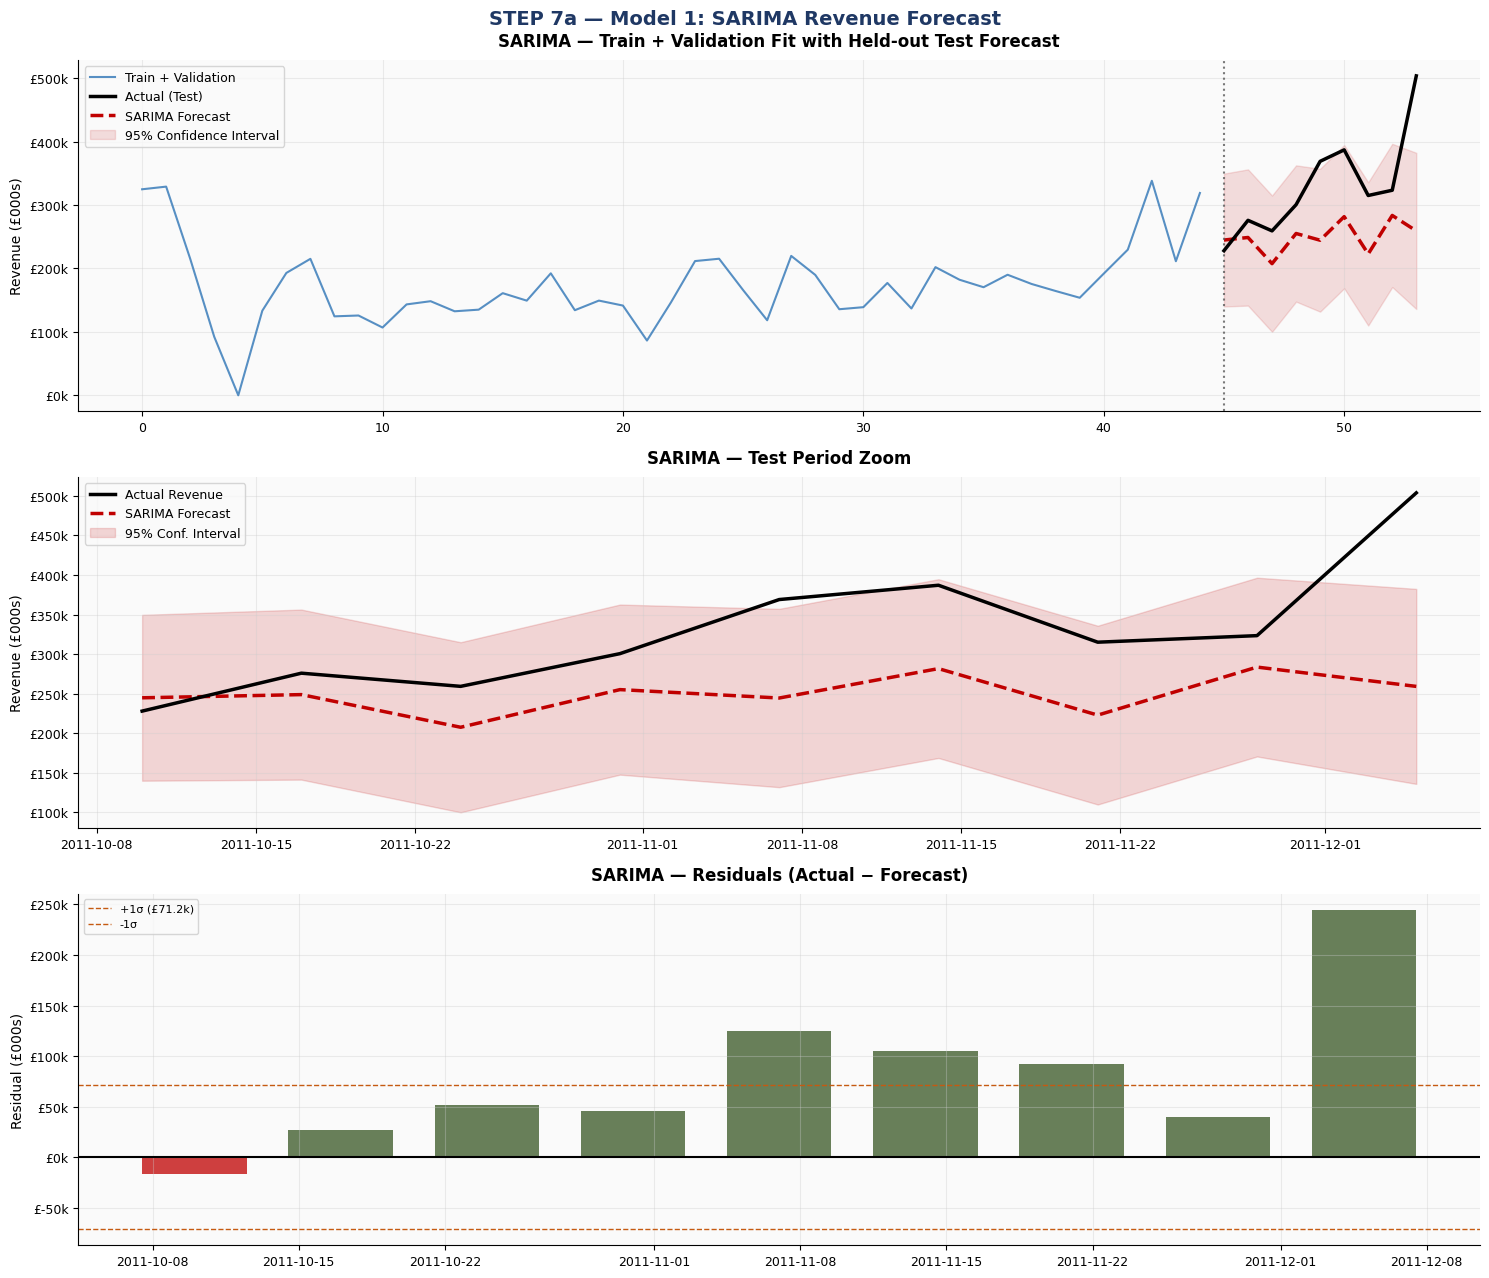

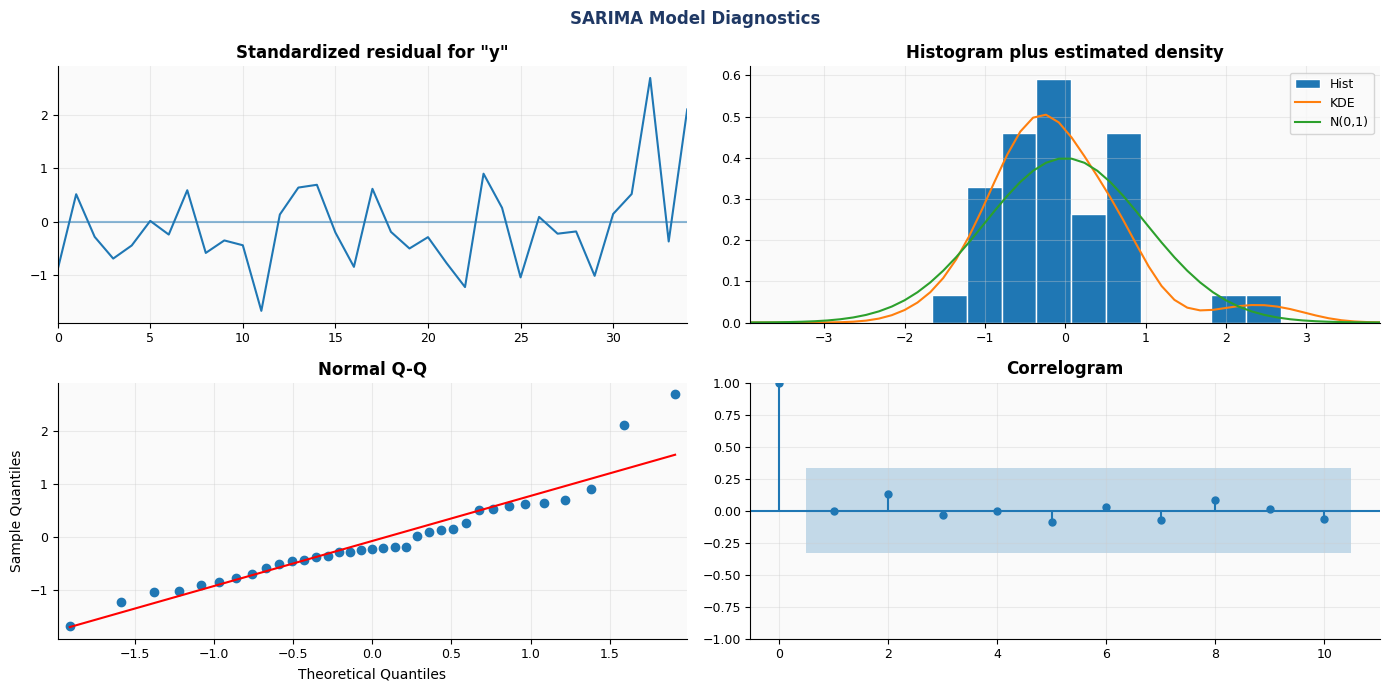


✅  SARIMA validation, refit, and held-out test evaluation complete.


In [10]:
print("=" * 65)
print("  STEP 7a — MODEL 1: SARIMA")
print("=" * 65)

sarima_d_train = 0 if adfuller(ts_train, autolag='AIC')[1] < 0.05 else 1

sarima_candidates = [
    {
        'name': 'SARIMA-A',
        'order': (1, sarima_d_train, 1),
        'seasonal_order': (1, 1, 1, 4),
        'trend': 'c',
    },
    {
        'name': 'SARIMA-B',
        'order': (2, sarima_d_train, 1),
        'seasonal_order': (1, 1, 0, 4),
        'trend': 'c',
    },
]

def fit_sarima(series, steps, config):
    model = SARIMAX(
        series,
        order=config['order'],
        seasonal_order=config['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend=config['trend'],
    )
    fit = model.fit(disp=False, maxiter=200)
    forecast = fit.get_forecast(steps=steps)
    pred = np.maximum(np.asarray(forecast.predicted_mean), 0)
    conf_int = forecast.conf_int()
    if hasattr(conf_int, 'iloc'):
        lower = np.maximum(conf_int.iloc[:, 0].values, 0)
        upper = conf_int.iloc[:, 1].values
    else:
        lower = np.maximum(conf_int[:, 0], 0)
        upper = conf_int[:, 1]
    return fit, pred, lower, upper

sarima_validation_rows = []
for config in sarima_candidates:
    fit_val, pred_val, _, _ = fit_sarima(ts_train, len(ts_val), config)
    sarima_validation_rows.append({
        'name': config['name'],
        'config': config,
        'fit': fit_val,
        'val_mape': mape_fn(ts_val, pred_val),
    })

sarima_validation_df = pd.DataFrame([
    {
        'Candidate': row['name'],
        'Validation_MAPE_%': round(row['val_mape'], 2),
        'Order': str(row['config']['order']),
        'Seasonal_Order': str(row['config']['seasonal_order']),
    }
    for row in sarima_validation_rows
]).sort_values('Validation_MAPE_%')

sarima_best_row = min(sarima_validation_rows, key=lambda row: row['val_mape'])
sarima_selected_config = sarima_best_row['config']
sarima_val_mape = sarima_best_row['val_mape']

print("\n  Validation candidate scores:")
print(sarima_validation_df.to_string(index=False))
print(f"\n  Selected SARIMA config: {sarima_best_row['name']}  (validation MAPE = {sarima_val_mape:.2f}%)")

sarima_fit, sarima_pred, ci_lower, ci_upper = fit_sarima(ts_trainval, len(ts_test), sarima_selected_config)

print(f"\n  Final model fit statistics (train + validation fit):")
print(f"    AIC   : {sarima_fit.aic:.2f}")
print(f"    BIC   : {sarima_fit.bic:.2f}")
print(f"    HQIC  : {sarima_fit.hqic:.2f}")

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

trainval_x = range(len(ts_trainval))
test_x = range(len(ts_trainval), len(ts_trainval) + len(ts_test))
test_dates_dt = [pd.Timestamp(d) for d in dates_test]

ax = axes[0]
ax.plot(trainval_x, ts_trainval/1000, color=C_BLUE, linewidth=1.5, label='Train + Validation', alpha=0.8)
ax.plot(test_x, ts_test/1000, color='black', linewidth=2.5, label='Actual (Test)', zorder=5)
ax.plot(test_x, sarima_pred/1000, color=C_RED, linewidth=2.5, linestyle='--', label='SARIMA Forecast')
ax.fill_between(test_x, ci_lower/1000, ci_upper/1000, color=C_RED, alpha=0.12, label='95% Confidence Interval')
ax.axvline(len(ts_trainval), color=C_GRAY, linewidth=1.5, linestyle=':', alpha=0.8)
ax.set_title("SARIMA — Train + Validation Fit with Held-out Test Forecast", pad=10)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(loc='upper left')

ax2 = axes[1]
ax2.plot(test_dates_dt, ts_test/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=5)
ax2.plot(test_dates_dt, sarima_pred/1000, color=C_RED, linewidth=2.5, linestyle='--', label='SARIMA Forecast')
ax2.fill_between(test_dates_dt, ci_lower/1000, ci_upper/1000, color=C_RED, alpha=0.15, label='95% Conf. Interval')
ax2.set_title("SARIMA — Test Period Zoom", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend()

ax3 = axes[2]
residuals_s = ts_test - sarima_pred
ax3.bar(test_dates_dt, residuals_s/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_s], alpha=0.75, width=5)
ax3.axhline(0, color='black', linewidth=1.5)
ax3.axhline(residuals_s.std()/1000, color=C_AMBER, linewidth=1, linestyle='--', label=f'+1σ (£{residuals_s.std()/1000:,.1f}k)')
ax3.axhline(-residuals_s.std()/1000, color=C_AMBER, linewidth=1, linestyle='--', label='-1σ')
ax3.set_title("SARIMA — Residuals (Actual − Forecast)", pad=10)
ax3.set_ylabel("Residual (£000s)")
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax3.legend(fontsize=8)

plt.suptitle("STEP 7a — Model 1: SARIMA Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

fig2 = sarima_fit.plot_diagnostics(figsize=(14, 7))
fig2.suptitle("SARIMA Model Diagnostics", fontsize=12, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  SARIMA validation, refit, and held-out test evaluation complete.")


## CELL 10 — STEP 7b: MODEL 2 — PROPHET

STEP 7b — MODEL 2: FACEBOOK PROPHET

**Why Prophet for sales revenue forecasting:**

- Handles trend shifts and holiday effects well
- Offers business-friendly decomposition of trend and seasonality
- Works well on aggregated retail series with event-driven demand

**Validation workflow used here:**

- Two Prophet configurations are compared on the validation window
- The selected configuration is refit on train + validation
- Final reporting uses the held-out test window only


In [11]:
print("=" * 65)
print("  STEP 7b — MODEL 2: FACEBOOK PROPHET")
print("=" * 65)

black_friday = pd.DataFrame({
    'holiday': 'black_friday',
    'ds':  pd.to_datetime(['2009-11-27', '2010-11-26', '2011-11-25']),
    'lower_window': -2,
    'upper_window':  1,
})
christmas = pd.DataFrame({
    'holiday': 'christmas_season',
    'ds':  pd.to_datetime(['2009-12-01', '2010-12-01', '2011-12-01']),
    'lower_window':  0,
    'upper_window': 24,
})
valentines = pd.DataFrame({
    'holiday': 'valentines',
    'ds':  pd.to_datetime(['2010-02-14', '2011-02-14']),
    'lower_window': -7,
    'upper_window':  0,
})
holidays_df = pd.concat([black_friday, christmas, valentines], ignore_index=True)

if not PROPHET_AVAILABLE:
    print("\n  ⚠️  Prophet not installed.")
    print("  Run this in a new cell first:  !pip install prophet --quiet")
    print("  Then restart runtime and run all cells again.")
    print("\n  Skipping Prophet — results table will exclude this model.")
    prophet_pred = np.full(len(ts_test), np.nan)
    prophet_lower = np.full(len(ts_test), np.nan)
    prophet_upper = np.full(len(ts_test), np.nan)
    prophet_val_mape = np.nan
    prophet_selected_config = None
    prophet_model_final = None
else:
    prophet_candidates = [
        {
            'name': 'Prophet-A',
            'params': {
                'changepoint_prior_scale': 0.05,
                'seasonality_prior_scale': 10.0,
                'holidays_prior_scale': 10.0,
            },
        },
        {
            'name': 'Prophet-B',
            'params': {
                'changepoint_prior_scale': 0.20,
                'seasonality_prior_scale': 5.0,
                'holidays_prior_scale': 15.0,
            },
        },
    ]

    def fit_prophet(train_dates, train_values, forecast_dates, params):
        train_df = pd.DataFrame({
            'ds': pd.to_datetime(train_dates),
            'y': np.asarray(train_values, dtype=float),
        })
        model = Prophet(
            seasonality_mode='additive',
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            holidays=holidays_df,
            interval_width=0.95,
            **params,
        )
        model.fit(train_df)
        future_df = pd.DataFrame({'ds': pd.to_datetime(forecast_dates)})
        forecast = model.predict(future_df)
        pred = np.maximum(forecast['yhat'].values, 0)
        lower = np.maximum(forecast['yhat_lower'].values, 0)
        upper = forecast['yhat_upper'].values
        return model, pred, lower, upper

    prophet_validation_rows = []
    for candidate in prophet_candidates:
        model_val, pred_val, _, _ = fit_prophet(dates_train, ts_train, dates_val, candidate['params'])
        prophet_validation_rows.append({
            'name': candidate['name'],
            'params': candidate['params'],
            'val_mape': mape_fn(ts_val, pred_val),
            'model_val': model_val,
        })

    prophet_validation_df = pd.DataFrame([
        {
            'Candidate': row['name'],
            'Validation_MAPE_%': round(row['val_mape'], 2),
            'changepoint_prior_scale': row['params']['changepoint_prior_scale'],
            'seasonality_prior_scale': row['params']['seasonality_prior_scale'],
        }
        for row in prophet_validation_rows
    ]).sort_values('Validation_MAPE_%')

    prophet_best_row = min(prophet_validation_rows, key=lambda row: row['val_mape'])
    prophet_selected_config = prophet_best_row['params']
    prophet_val_mape = prophet_best_row['val_mape']

    print("\n  Validation candidate scores:")
    print(prophet_validation_df.to_string(index=False))
    print(f"\n  Selected Prophet config: {prophet_best_row['name']}  (validation MAPE = {prophet_val_mape:.2f}%)")

    prophet_model_final, prophet_pred, prophet_lower, prophet_upper = fit_prophet(
        dates_trainval,
        ts_trainval,
        dates_test,
        prophet_selected_config,
    )

    test_dates_dt_p = [pd.Timestamp(d) for d in dates_test]

    fig, axes = plt.subplots(3, 1, figsize=(15, 14))

    ax = axes[0]
    ax.plot(pd.to_datetime(dates_trainval), ts_trainval/1000, color=C_BLUE, linewidth=1.5, alpha=0.7, label='Train + Validation')
    ax.plot(test_dates_dt_p, ts_test/1000, color='black', linewidth=2.5, label='Actual (Test)', zorder=5)
    ax.plot(test_dates_dt_p, prophet_pred/1000, color=C_AMBER, linewidth=2.5, linestyle='--', label='Prophet Forecast')
    ax.fill_between(test_dates_dt_p, prophet_lower/1000, prophet_upper/1000, color=C_AMBER, alpha=0.2, label='95% Uncertainty Interval')
    ax.set_title("Prophet — Train + Validation Fit with Held-out Test Forecast", pad=10)
    ax.set_ylabel("Revenue (£000s)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
    ax.legend(loc='upper left')

    ax2 = axes[1]
    component_dates = pd.date_range(pd.Timestamp(dates_trainval[0]), pd.Timestamp(dates_test[-1]), freq='W-MON')
    component_df = pd.DataFrame({'ds': component_dates})
    full_fc = prophet_model_final.predict(component_df)
    ax2.plot(full_fc['ds'], full_fc['trend']/1000, color=C_NAVY, linewidth=2, label='Trend component')
    ax2.fill_between(full_fc['ds'], (full_fc['trend'] + full_fc['yearly'])/1000, full_fc['trend']/1000, alpha=0.3, color=C_BLUE, label='Yearly seasonality')
    ax2.set_title("Prophet — Trend + Yearly Seasonality", pad=10)
    ax2.set_ylabel("Revenue (£000s)")
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
    ax2.legend()

    ax3 = axes[2]
    residuals_p = ts_test - prophet_pred
    ax3.bar(test_dates_dt_p, residuals_p/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_p], alpha=0.75, width=5)
    ax3.axhline(0, color='black', linewidth=1.5)
    ax3.set_title("Prophet — Residuals (Actual − Forecast)", pad=10)
    ax3.set_ylabel("Residual (£000s)")
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

    plt.suptitle("STEP 7b — Model 2: Prophet Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
    plt.tight_layout()
    plt.show()

    fig_comp = prophet_model_final.plot_components(full_fc)
    fig_comp.suptitle("Prophet — Full Component Decomposition", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n✅  Prophet validation, refit, and held-out test evaluation complete.")


  STEP 7b — MODEL 2: FACEBOOK PROPHET

  ⚠️  Prophet not installed.
  Run this in a new cell first:  !pip install prophet --quiet
  Then restart runtime and run all cells again.

  Skipping Prophet — results table will exclude this model.


## CELL 11 — STEP 7c: MODEL 3 — GRADIENT BOOSTING

STEP 7c — MODEL 3: GRADIENT BOOSTING

**Why Gradient Boosting for sales revenue forecasting:**

- Captures non-linear interactions across lags, price, and seasonality
- Handles retail volatility better than purely linear models
- Produces feature importance for operational interpretation

**Validation workflow used here:**

- Two hyperparameter sets are compared on the validation window
- The selected set is refit on train + validation
- Final reporting uses the held-out test window only


  STEP 7c — MODEL 3: GRADIENT BOOSTING

  Validation candidate scores:
  Candidate  Validation_MAPE_%  learning_rate  max_depth  subsample
  GB-Normal              12.39           0.05          4       0.80
GB-Volatile              14.72           0.02          3       0.70

  Selected Gradient Boosting config: GB-Normal  (validation MAPE = 12.39%)


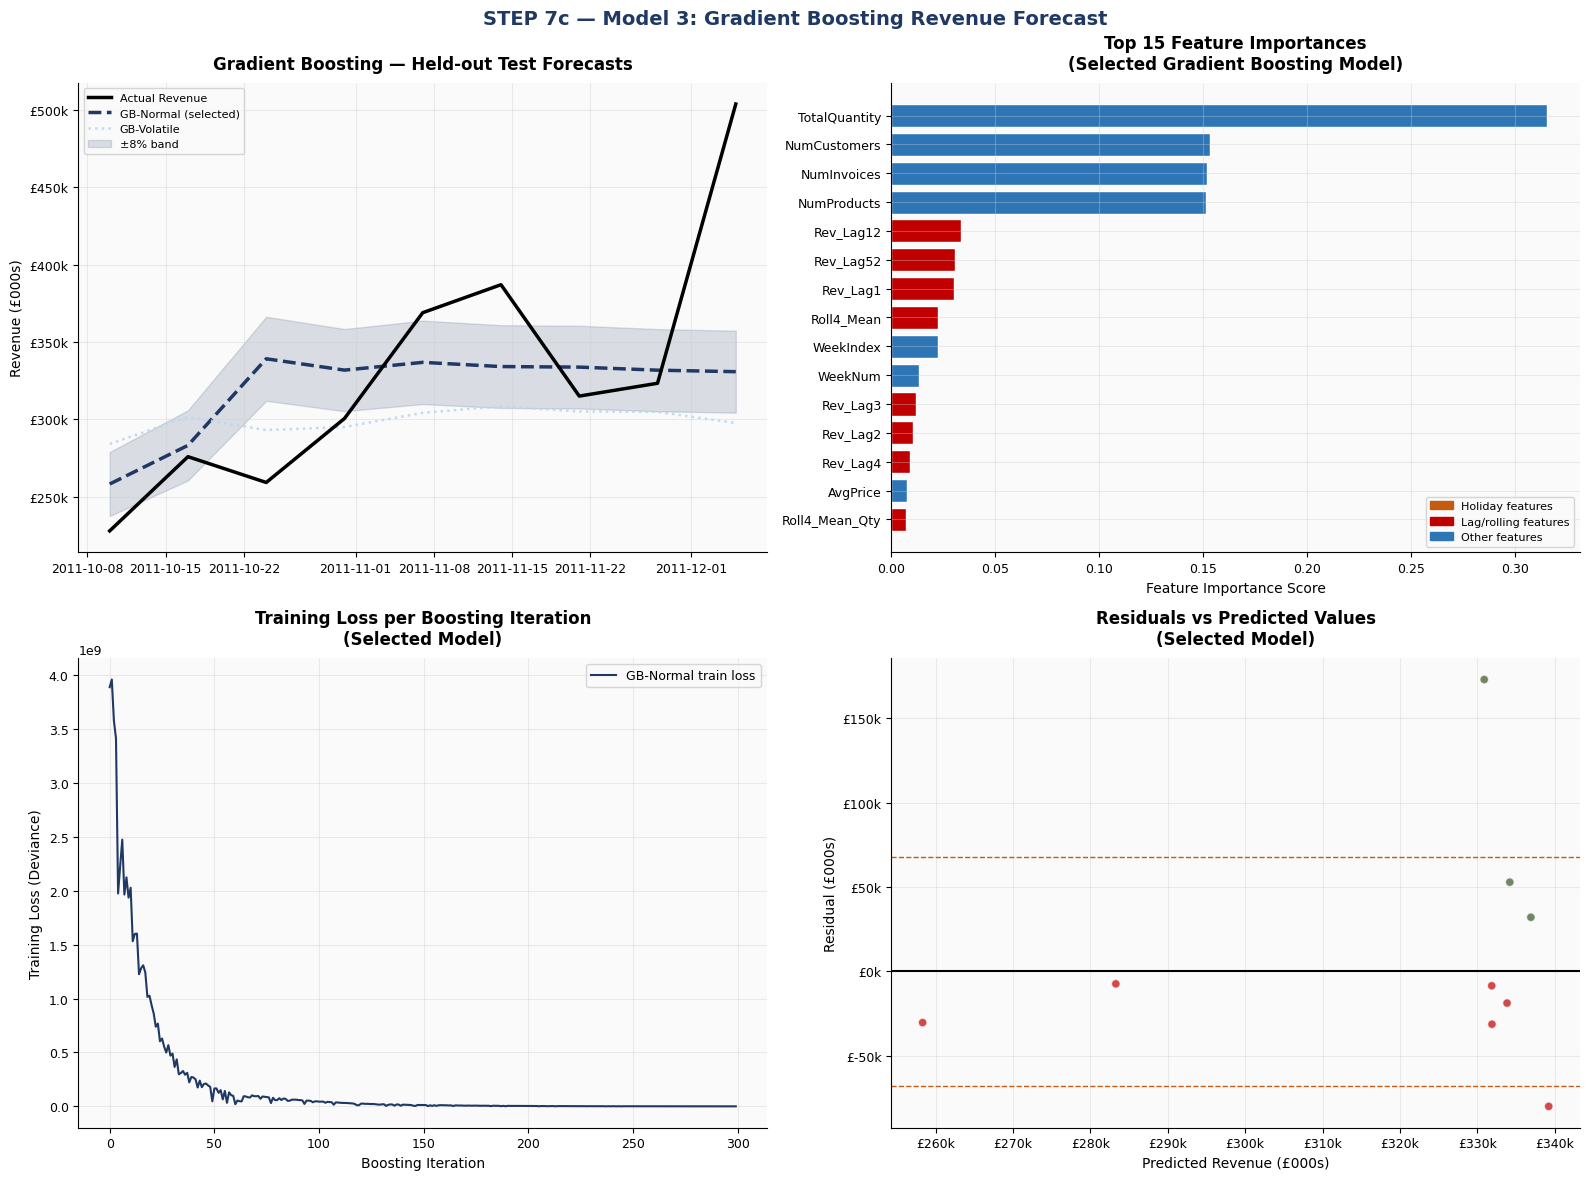


  Top 10 feature importances:
  Feature                  Importance    Cumulative
  ------------------------------------------------
  TotalQuantity                0.3157        31.6%
  NumCustomers                 0.1532        46.9%
  NumInvoices                  0.1521        62.1%
  NumProducts                  0.1514        77.2%
  Rev_Lag12                    0.0337        80.6%
  Rev_Lag52                    0.0305        83.7%
  Rev_Lag1                     0.0301        86.7%
  Roll4_Mean                   0.0227        88.9%
  WeekIndex                    0.0222        91.2%
  WeekNum                      0.0135        92.5%

✅  Gradient Boosting validation, refit, and held-out test evaluation complete.


In [12]:
print("=" * 65)
print("  STEP 7c — MODEL 3: GRADIENT BOOSTING")
print("=" * 65)

gb_candidates = [
    {
        'name': 'GB-Normal',
        'params': {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 4,
            'max_features': 'sqrt',
            'min_samples_leaf': 3,
            'min_samples_split': 6,
            'subsample': 0.8,
            'random_state': 42,
        },
    },
    {
        'name': 'GB-Volatile',
        'params': {
            'n_estimators': 300,
            'learning_rate': 0.02,
            'max_depth': 3,
            'max_features': 'sqrt',
            'min_samples_leaf': 5,
            'min_samples_split': 10,
            'subsample': 0.7,
            'random_state': 42,
        },
    },
]

gb_validation_rows = []
gb_test_candidates = {}

for candidate in gb_candidates:
    model_val = GradientBoostingRegressor(**candidate['params'])
    model_val.fit(X_train, y_train)
    val_pred = np.maximum(model_val.predict(X_val), 0)
    val_mape = mape_fn(y_val, val_pred)
    gb_validation_rows.append({
        'name': candidate['name'],
        'params': candidate['params'],
        'val_mape': val_mape,
    })

gb_validation_df = pd.DataFrame([
    {
        'Candidate': row['name'],
        'Validation_MAPE_%': round(row['val_mape'], 2),
        'learning_rate': row['params']['learning_rate'],
        'max_depth': row['params']['max_depth'],
        'subsample': row['params']['subsample'],
    }
    for row in gb_validation_rows
]).sort_values('Validation_MAPE_%')

gb_best_row = min(gb_validation_rows, key=lambda row: row['val_mape'])
gb_best_name = gb_best_row['name']
gb_best_params = gb_best_row['params']
gb_val_mape = gb_best_row['val_mape']

print("\n  Validation candidate scores:")
print(gb_validation_df.to_string(index=False))
print(f"\n  Selected Gradient Boosting config: {gb_best_name}  (validation MAPE = {gb_val_mape:.2f}%)")

for candidate in gb_candidates:
    model_test = GradientBoostingRegressor(**candidate['params'])
    model_test.fit(X_trainval, y_trainval)
    pred_test = np.maximum(model_test.predict(X_test), 0)
    gb_test_candidates[candidate['name']] = {
        'model': model_test,
        'pred': pred_test,
    }

best_gb = gb_test_candidates[gb_best_name]['model']
gb_pred = gb_test_candidates[gb_best_name]['pred']
gb_alt_name = [candidate['name'] for candidate in gb_candidates if candidate['name'] != gb_best_name][0]
gb_pred_alt = gb_test_candidates[gb_alt_name]['pred']
feat_imp = pd.Series(best_gb.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
test_dates_dt = [pd.Timestamp(d) for d in dates_test]

ax = axes[0, 0]
ax.plot(test_dates_dt, y_test/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=5)
ax.plot(test_dates_dt, gb_pred/1000, color=C_NAVY, linewidth=2.5, linestyle='--', label=f'{gb_best_name} (selected)')
ax.plot(test_dates_dt, gb_pred_alt/1000, color=C_LTBLUE, linewidth=1.8, linestyle=':', label=f'{gb_alt_name}', alpha=0.9)
ax.fill_between(test_dates_dt, gb_pred/1000*0.92, gb_pred/1000*1.08, alpha=0.15, color=C_NAVY, label='±8% band')
ax.set_title("Gradient Boosting — Held-out Test Forecasts", pad=10)
ax.set_ylabel("Revenue (£000s)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax.legend(fontsize=8)

ax2 = axes[0, 1]
top15 = feat_imp.head(15)
colors_fi = [C_AMBER if 'Holiday' in f or 'Pre' in f or 'Post' in f else C_RED if 'Rev_Lag' in f or 'Roll' in f else C_BLUE for f in top15.index]
ax2.barh(top15.index[::-1], top15.values[::-1], color=colors_fi[::-1], edgecolor='white')
ax2.set_title("Top 15 Feature Importances\n(Selected Gradient Boosting Model)", pad=10)
ax2.set_xlabel("Feature Importance Score")
handles = [
    mpatches.Patch(color=C_AMBER, label='Holiday features'),
    mpatches.Patch(color=C_RED, label='Lag/rolling features'),
    mpatches.Patch(color=C_BLUE, label='Other features'),
]
ax2.legend(handles=handles, fontsize=8, loc='lower right')

ax3 = axes[1, 0]
ax3.plot(range(len(best_gb.train_score_)), best_gb.train_score_, color=C_NAVY, linewidth=1.5, label=f'{gb_best_name} train loss')
ax3.set_title("Training Loss per Boosting Iteration\n(Selected Model)", pad=10)
ax3.set_xlabel("Boosting Iteration")
ax3.set_ylabel("Training Loss (Deviance)")
ax3.legend()

ax4 = axes[1, 1]
residuals_gb = y_test - gb_pred
ax4.scatter(gb_pred/1000, residuals_gb/1000, alpha=0.7, color=[C_GREEN if r > 0 else C_RED for r in residuals_gb], s=40, edgecolors='white')
ax4.axhline(0, color='black', linewidth=1.5)
ax4.axhline(residuals_gb.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.axhline(-residuals_gb.std()/1000, color=C_AMBER, linestyle='--', linewidth=1)
ax4.set_title("Residuals vs Predicted Values\n(Selected Model)", pad=10)
ax4.set_xlabel("Predicted Revenue (£000s)")
ax4.set_ylabel("Residual (£000s)")
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))

plt.suptitle("STEP 7c — Model 3: Gradient Boosting Revenue Forecast", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n  Top 10 feature importances:")
print(f"  {'Feature':<22} {'Importance':>12}  {'Cumulative':>12}")
print("  " + "-" * 48)
cumsum = 0
for feat, imp in feat_imp.head(10).items():
    cumsum += imp
    print(f"  {feat:<22} {imp:>12.4f}  {cumsum:>11.1%}")

print("\n✅  Gradient Boosting validation, refit, and held-out test evaluation complete.")


## CELL 12 — STEP 8: MODEL EVALUATION (MAPE — Primary Metric)

STEP 8 — MODEL EVALUATION & SELECTION

**Primary metric: MAPE (Mean Absolute Percentage Error)**

```
┌──────────────────────────────────────────────────────────────────┐
│  MAPE = (1/n) × Σ | (Actual − Forecast) / Actual | × 100        │
│  Reported on scale 0–100 (lower = better)                       │
└──────────────────────────────────────────────────────────────────┘
```

- Lower MAPE = better forecast
- Reported as a percentage on the 0–100 scale
- RMSE is intentionally omitted per professor guidance

**Selection procedure used here:**

1. Tune each model on the validation window only
2. Select the final model using the lowest validation MAPE
3. Report held-out test MAPE and MAE without using test for model selection
4. Retrain the selected model on full history for the forward forecast


  STEP 8 — MODEL EVALUATION & SELECTION (MAPE)

  Model                  Val MAPE     Test MAPE    Test MAE (£)   Selected?
  ──────────────────────────────────────────────────────────────────────────────
    SARIMA                   18.28%      22.58%   £    83,019   No
   ★Gradient Boosting        12.39%      13.60%   £    48,197   ★ YES (lowest val MAPE)

  Selected final model (lowest validation MAPE): Gradient Boosting
    Validation MAPE : 12.39%
    Held-out test MAPE : 13.60%
    Held-out test MAE  : £48,197

  Lowest held-out test MAPE observed: Gradient Boosting (13.60%)


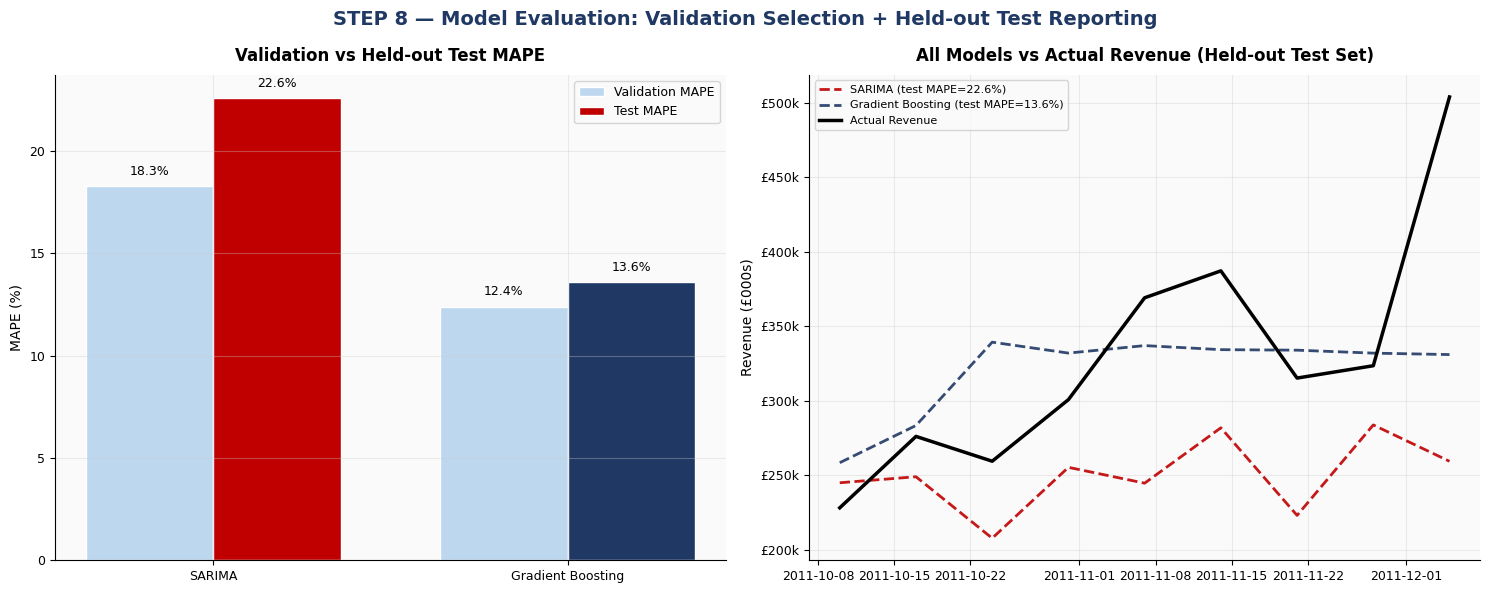


✅  Model evaluation complete. Final model selected by validation MAPE: Gradient Boosting


In [13]:
print("=" * 65)
print("  STEP 8 — MODEL EVALUATION & SELECTION (MAPE)")
print("=" * 65)

results = {
    'SARIMA': {
        'Validation_MAPE': sarima_val_mape,
        'MAPE': mape_fn(ts_test, sarima_pred),
        'MAE': mae_fn(ts_test, sarima_pred),
        'pred': sarima_pred,
        'actual': ts_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_RED,
    },
    'Gradient Boosting': {
        'Validation_MAPE': gb_val_mape,
        'MAPE': mape_fn(y_test, gb_pred),
        'MAE': mae_fn(y_test, gb_pred),
        'pred': gb_pred,
        'actual': y_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_NAVY,
    },
}

if PROPHET_AVAILABLE and not np.isnan(prophet_pred).all():
    results['Prophet'] = {
        'Validation_MAPE': prophet_val_mape,
        'MAPE': mape_fn(ts_test, prophet_pred),
        'MAE': mae_fn(ts_test, prophet_pred),
        'pred': prophet_pred,
        'actual': ts_test,
        'dates': [pd.Timestamp(d) for d in dates_test],
        'color': C_AMBER,
    }

best_name = min(results, key=lambda k: results[k]['Validation_MAPE'])
best_test_name = min(results, key=lambda k: results[k]['MAPE'])

print(f"\n  {'Model':<22} {'Val MAPE':<12} {'Test MAPE':<12} {'Test MAE (£)':<14} {'Selected?'}")
print("  " + "─" * 78)
for name, r in results.items():
    marker = " ★" if name == best_name else "  "
    selected = '★ YES (lowest val MAPE)' if name == best_name else 'No'
    print(
        f"  {marker}{name:<21} "
        f"{r['Validation_MAPE']:>8.2f}%   "
        f"{r['MAPE']:>8.2f}%   "
        f"£{r['MAE']:>10,.0f}   {selected}"
    )

print(f"\n  Selected final model (lowest validation MAPE): {best_name}")
print(f"    Validation MAPE : {results[best_name]['Validation_MAPE']:.2f}%")
print(f"    Held-out test MAPE : {results[best_name]['MAPE']:.2f}%")
print(f"    Held-out test MAE  : £{results[best_name]['MAE']:,.0f}")
print(f"\n  Lowest held-out test MAPE observed: {best_test_name} ({results[best_test_name]['MAPE']:.2f}%)")

names = list(results.keys())
colors = [results[n]['color'] for n in names]
val_mape_v = [results[n]['Validation_MAPE'] for n in names]
test_mape_v = [results[n]['MAPE'] for n in names]
mae_v = [results[n]['MAE'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
x = np.arange(len(names))
width = 0.36
val_bars = ax.bar(x - width/2, val_mape_v, width, color=C_LTBLUE, edgecolor='white', label='Validation MAPE')
test_bars = ax.bar(x + width/2, test_mape_v, width, color=colors, edgecolor='white', label='Test MAPE')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_title("Validation vs Held-out Test MAPE", pad=10)
ax.set_ylabel("MAPE (%)")
ax.legend()
for bars in [val_bars, test_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.4, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
for name, r in results.items():
    ax2.plot(r['dates'], r['pred']/1000, color=r['color'], linewidth=2, linestyle='--', label=f"{name} (test MAPE={r['MAPE']:.1f}%)", alpha=0.9)
ax2.plot(results[best_name]['dates'], results[best_name]['actual']/1000, color='black', linewidth=2.5, label='Actual Revenue', zorder=10)
ax2.set_title("All Models vs Actual Revenue (Held-out Test Set)", pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=8)

plt.suptitle("STEP 8 — Model Evaluation: Validation Selection + Held-out Test Reporting", fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print(f"\n✅  Model evaluation complete. Final model selected by validation MAPE: {best_name}")


## CELL 12b — STEP 8b: TEST SET — MAPE BY TIME PERIOD + ERROR BOX PLOTS

STEP 8b — TEST PERIOD BREAKDOWN

**Per professor guidance:**
- Divide the held-out test set into **3 or 4 equal time periods**
- Report **MAPE for each period** on the 0–100 scale
- Show the distribution of percentage errors by period

This notebook automatically chooses 4 periods when possible; otherwise it uses 3 equal periods.


  STEP 8b — TEST MAPE BY TIME PERIOD + ERROR BOX PLOTS

  Selected model: Gradient Boosting
  Test set: 9 weeks divided into 3 equal periods of 3 weeks each

  Period                                     MAPE (0-100)
  --------------------------------------------------------
  Period 1 (10 Oct 2011–24 Oct 2011)            15.58%
  Period 2 (31 Oct 2011–14 Nov 2011)            10.92%
  Period 3 (21 Nov 2011–05 Dec 2011)            14.29%


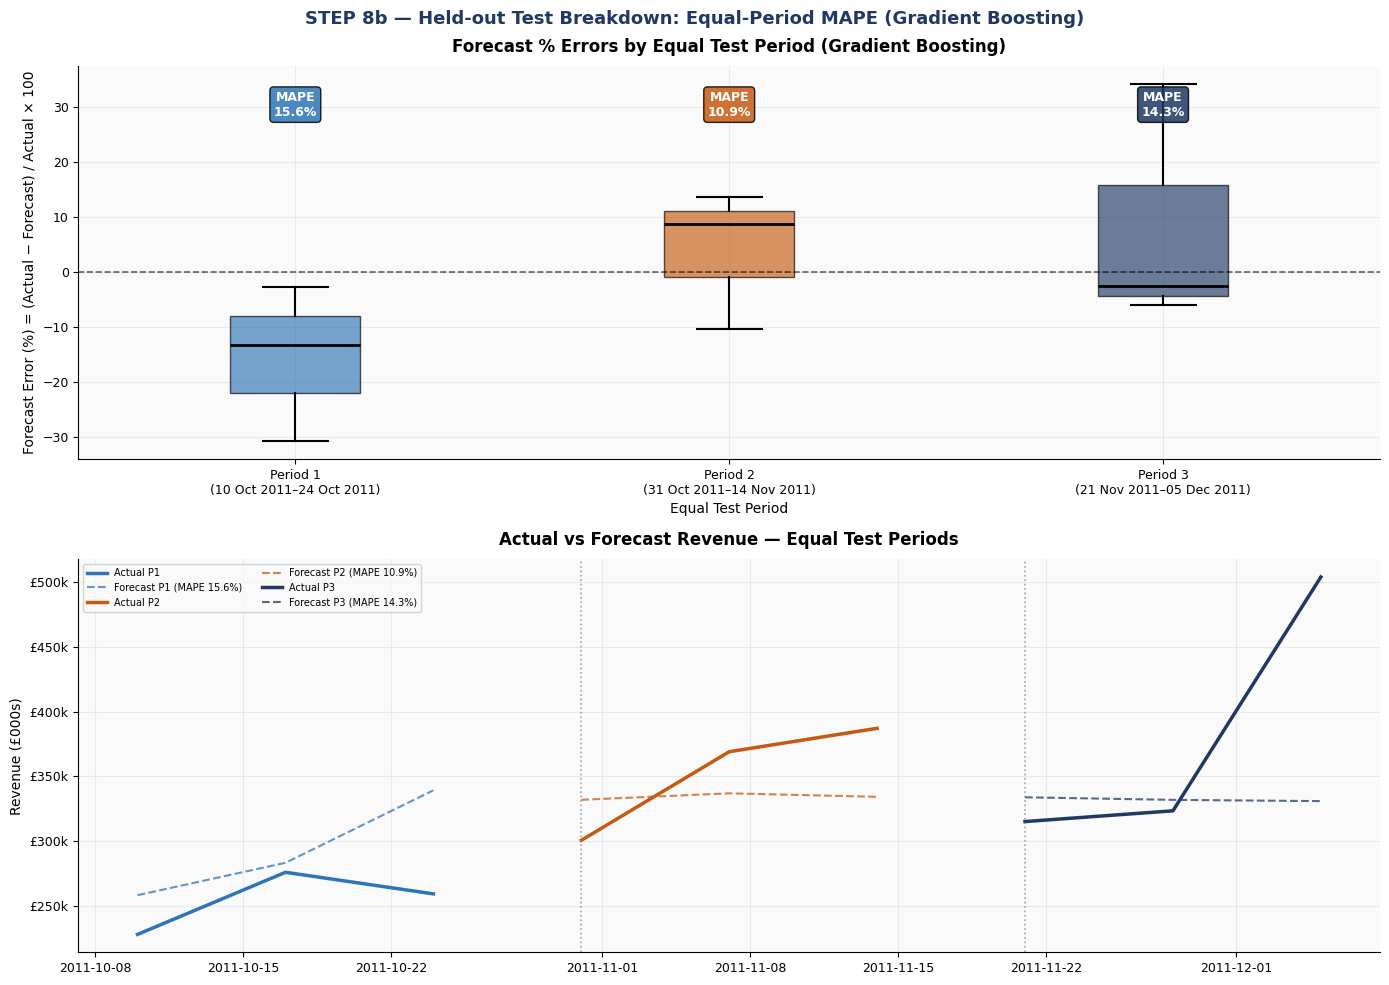


✅  Equal-period test MAPE reporting complete.


In [14]:
print("=" * 65)
print("  STEP 8b — TEST MAPE BY TIME PERIOD + ERROR BOX PLOTS")
print("=" * 65)

best_actual = results[best_name]['actual']
best_pred = results[best_name]['pred']
best_dates = results[best_name]['dates']
n_test = len(best_actual)

n_periods = test_period_count
period_size = n_test // n_periods
periods = []
period_summary_rows = []

for p in range(n_periods):
    start = p * period_size
    end = start + period_size
    act_p = best_actual[start:end]
    pred_p = best_pred[start:end]
    d_p = best_dates[start:end]
    pct_err = np.where(act_p != 0, (act_p - pred_p) / act_p * 100, np.nan)
    mape_p = float(np.nanmean(np.abs(pct_err)))
    d_start = pd.Timestamp(d_p[0]).strftime('%d %b %Y')
    d_end = pd.Timestamp(d_p[-1]).strftime('%d %b %Y')
    label = f"Period {p+1}\n({d_start}–{d_end})"
    period_record = {
        'period_number': p + 1,
        'label': label,
        'short': f"P{p+1}",
        'mape': mape_p,
        'pct_errors': pct_err[~np.isnan(pct_err)],
        'dates': d_p,
        'actual': act_p,
        'pred': pred_p,
    }
    periods.append(period_record)
    period_summary_rows.append({
        'Model': best_name,
        'Period': f"Period {p+1}",
        'Start_Date': pd.Timestamp(d_p[0]).date(),
        'End_Date': pd.Timestamp(d_p[-1]).date(),
        'Weeks': len(d_p),
        'MAPE_%': round(mape_p, 4),
    })

period_summary_df = pd.DataFrame(period_summary_rows)

print(f"\n  Selected model: {best_name}")
print(f"  Test set: {n_test} weeks divided into {n_periods} equal periods of {period_size} weeks each")
print(f"\n  {'Period':<42} {'MAPE (0-100)'}")
print("  " + "-" * 56)
for p in periods:
    lbl = p['label'].replace('\n', ' ')
    print(f"  {lbl:<42} {p['mape']:>8.2f}%")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
bp_colors = [C_BLUE, C_AMBER, C_NAVY, C_RED][:n_periods]

ax = axes[0]
bp_data = [p['pct_errors'] for p in periods]
bp_labels = [p['label'] for p in periods]
bp = ax.boxplot(
    bp_data,
    labels=bp_labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=5, alpha=0.5),
)
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_title(f"Forecast % Errors by Equal Test Period ({best_name})", pad=10, fontsize=12)
ax.set_ylabel("Forecast Error (%) = (Actual − Forecast) / Actual × 100")
ax.set_xlabel("Equal Test Period")
ylim = ax.get_ylim()
for i, p in enumerate(periods, start=1):
    ax.text(i, ylim[1] * 0.88, f"MAPE\n{p['mape']:.1f}%", ha='center', va='top', fontsize=9, fontweight='bold', color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=bp_colors[i-1], alpha=0.85))

ax2 = axes[1]
for p, color in zip(periods, bp_colors):
    ax2.plot(p['dates'], p['actual']/1000, color=color, linewidth=2.5, label=f"Actual {p['short']}")
    ax2.plot(p['dates'], p['pred']/1000, color=color, linewidth=1.5, linestyle='--', alpha=0.75, label=f"Forecast {p['short']} (MAPE {p['mape']:.1f}%)")
for p in periods[1:]:
    ax2.axvline(p['dates'][0], color='gray', linewidth=1.2, linestyle=':', alpha=0.7)
ax2.set_title("Actual vs Forecast Revenue — Equal Test Periods", pad=10, fontsize=12)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=7, ncol=2)

plt.suptitle(f"STEP 8b — Held-out Test Breakdown: Equal-Period MAPE ({best_name})", fontsize=13, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()

print("\n✅  Equal-period test MAPE reporting complete.")


## CELL 13 — STEP 9: ALGORITHMIC SOLUTION FINALIZATION

STEP 9 — ALGORITHMIC SOLUTION FINALIZATION

**Algorithmic solution finalization:**

- Use the model selected by the lowest validation MAPE
- Keep the test window untouched for reporting only
- Retrain the selected model on the full historical data
- Generate a 12-week forward revenue forecast
- Use rolling lag updates for the machine-learning forecast


In [15]:
print("=" * 65)
print("  STEP 9 — ALGORITHMIC SOLUTION FINALIZATION")
print("=" * 65)
print(f"\n  Selected model (lowest validation MAPE): {best_name}")
print(f"  Retraining on full dataset ({len(weekly)} historical weeks)...")

FORECAST_WEEKS = 12
ts_full_history = weekly['TotalRevenue'].values.astype(float)
dates_full_history = pd.to_datetime(weekly['WeekStart']).values

if best_name == 'SARIMA':
    final_sarima = SARIMAX(
        ts_full_history,
        order=sarima_selected_config['order'],
        seasonal_order=sarima_selected_config['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
        trend=sarima_selected_config['trend'],
    )
    final_fit_s = final_sarima.fit(disp=False, maxiter=200)
    fcast_obj = final_fit_s.get_forecast(steps=FORECAST_WEEKS)
    future_rev = np.maximum(np.asarray(fcast_obj.predicted_mean), 0)
    ci_fut = fcast_obj.conf_int()
    if hasattr(ci_fut, 'iloc'):
        f_lower = np.maximum(ci_fut.iloc[:, 0].values, 0)
        f_upper = ci_fut.iloc[:, 1].values
    else:
        f_lower = np.maximum(ci_fut[:, 0], 0)
        f_upper = ci_fut[:, 1]
    future_dates = [pd.Timestamp(dates_full_history[-1]) + pd.Timedelta(weeks=i+1) for i in range(FORECAST_WEEKS)]
    print(f"  ✅ SARIMA retrained on {len(ts_full_history)} weeks.")

elif best_name == 'Prophet' and PROPHET_AVAILABLE:
    full_prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(dates_full_history),
        'y': ts_full_history,
    })
    final_prophet = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=holidays_df,
        interval_width=0.95,
        **prophet_selected_config,
    )
    final_prophet.fit(full_prophet_df)
    future_dates = [pd.Timestamp(dates_full_history[-1]) + pd.Timedelta(weeks=i+1) for i in range(FORECAST_WEEKS)]
    future_df_p = pd.DataFrame({'ds': future_dates})
    future_fc_p = final_prophet.predict(future_df_p)
    future_rev = np.maximum(future_fc_p['yhat'].values, 0)
    f_lower = np.maximum(future_fc_p['yhat_lower'].values, 0)
    f_upper = future_fc_p['yhat_upper'].values
    print(f"  ✅ Prophet retrained on {len(ts_full_history)} weeks.")

else:
    final_gb = GradientBoostingRegressor(**gb_best_params)
    final_gb.fit(X, y)

    extended = wdf[FEATURES + [TARGET]].copy()
    future_rev = []
    future_dates = []

    for step in range(FORECAST_WEEKS):
        next_date = pd.Timestamp(weekly['WeekStart'].iloc[-1]) + pd.Timedelta(weeks=step+1)
        future_dates.append(next_date)
        nr = {}
        nr['Year'] = next_date.year
        nr['Month'] = next_date.month
        nr['WeekNum'] = int(next_date.isocalendar()[1])
        nr['Quarter'] = (next_date.month - 1) // 3 + 1
        nr['HolidaySeason'] = int(next_date.month in [11, 12])
        nr['PreHoliday'] = int(next_date.month == 10)
        nr['PostHoliday'] = int(next_date.month == 1)
        nr['SummerPeak'] = int(next_date.month in [6, 7])

        hist = list(extended[TARGET].values)
        nr['Rev_Lag1'] = hist[-1]
        nr['Rev_Lag2'] = hist[-2] if len(hist) >= 2 else hist[-1]
        nr['Rev_Lag3'] = hist[-3] if len(hist) >= 3 else hist[-1]
        nr['Rev_Lag4'] = hist[-4] if len(hist) >= 4 else hist[-1]
        nr['Rev_Lag8'] = hist[-8] if len(hist) >= 8 else hist[-1]
        nr['Rev_Lag12'] = hist[-12] if len(hist) >= 12 else hist[-1]
        nr['Rev_Lag52'] = hist[-52] if len(hist) >= 52 else hist[-1]
        nr['Roll4_Mean'] = np.mean(hist[-4:])
        nr['Roll4_Std'] = np.std(hist[-4:])
        nr['Roll12_Mean'] = np.mean(hist[-12:])
        nr['Roll4_Mean_Qty'] = float(extended['TotalQuantity'].iloc[-4:].mean())
        nr['WeekIndex'] = float(extended['WeekIndex'].iloc[-1]) + step + 1
        nr['AvgPrice'] = float(extended['AvgPrice'].mean())
        nr['AvgPrice_Lag1'] = float(extended['AvgPrice'].iloc[-1])
        nr['NumInvoices'] = float(extended['NumInvoices'].mean())
        nr['NumProducts'] = float(extended['NumProducts'].mean())
        nr['NumCustomers'] = float(extended['NumCustomers'].mean())
        nr['TotalQuantity'] = float(extended['TotalQuantity'].iloc[-1])

        x_fut = np.array([nr[f] for f in FEATURES]).reshape(1, -1)
        pred = max(0, final_gb.predict(x_fut)[0])
        future_rev.append(pred)

        new_row = pd.DataFrame([{**nr, TARGET: pred}])
        extended = pd.concat([extended, new_row[FEATURES + [TARGET]]], ignore_index=True)

    future_rev = np.array(future_rev)
    f_lower = future_rev * 0.90
    f_upper = future_rev * 1.10
    print(f"  ✅ Gradient Boosting retrained on {len(X)} modeled weeks.")

print(f"\n  12-WEEK REVENUE FORECAST  [{best_name}]")
print(f"  {'Wk':>3}  {'Date':<13}  {'Forecast':>12}  {'Low (90%)':>12}  {'High (110%)':>12}  {'Flag'}")
print("  " + "─" * 68)
for i, (d, f, lo, hi) in enumerate(zip(future_dates, future_rev, f_lower, f_upper), 1):
    flag = "Holiday" if d.month in [11, 12] else ("PreHol" if d.month == 10 else "")
    print(f"  {i:>3}  {str(d.date()):<13}  £{f:>9,.0f}  £{lo:>9,.0f}  £{hi:>9,.0f}  {flag}")

print(f"\n  Total 12-week forecast : £{sum(future_rev):>12,.0f}")
print(f"  Avg weekly revenue     : £{np.mean(future_rev):>12,.0f}")
print(f"  Peak week              : Week {np.argmax(future_rev)+1}  (£{max(future_rev):,.0f})")

forecast_df = pd.DataFrame({
    'Week': range(1, FORECAST_WEEKS + 1),
    'WeekStart': [pd.Timestamp(d).date() for d in future_dates],
    'Forecast_Revenue': np.round(future_rev, 2),
    'Lower_Bound': np.round(f_lower, 2),
    'Upper_Bound': np.round(f_upper, 2),
    'HolidaySeason': [int(pd.Timestamp(d).month in [11, 12]) for d in future_dates],
})

print("\n✅  Finalization complete.")


  STEP 9 — ALGORITHMIC SOLUTION FINALIZATION

  Selected model (lowest validation MAPE): Gradient Boosting
  Retraining on full dataset (106 historical weeks)...


  ✅ Gradient Boosting retrained on 54 modeled weeks.

  12-WEEK REVENUE FORECAST  [Gradient Boosting]
   Wk  Date               Forecast     Low (90%)   High (110%)  Flag
  ────────────────────────────────────────────────────────────────────
    1  2011-12-12     £  296,690  £  267,021  £  326,358  Holiday
    2  2011-12-19     £  282,286  £  254,057  £  310,514  Holiday
    3  2011-12-26     £  292,900  £  263,610  £  322,190  Holiday
    4  2012-01-02     £  305,467  £  274,920  £  336,014  
    5  2012-01-09     £  293,089  £  263,780  £  322,398  
    6  2012-01-16     £  300,273  £  270,245  £  330,300  
    7  2012-01-23     £  288,984  £  260,086  £  317,883  
    8  2012-01-30     £  288,702  £  259,832  £  317,572  
    9  2012-02-06     £  285,948  £  257,353  £  314,543  
   10  2012-02-13     £  288,192  £  259,373  £  317,011  
   11  2012-02-20     £  290,048  £  261,044  £  319,053  
   12  2012-02-27     £  294,067  £  264,660  £  323,474  

  Total 12-week forecast : £

## CELL 14 — STEP 10: FULL FORECAST DASHBOARD

STEP 10 — OPERATIONAL FORECAST DASHBOARD

**Corporate-grade dashboard presenting:**

1. Historical revenue plus 12-week forward forecast
2. Transition zoom from history into forecast
3. Validation MAPE vs held-out test MAPE by model
4. Feature importance for the selected ML model
5. Residual analysis for the selected model on test data
6. Forecast confidence band detail


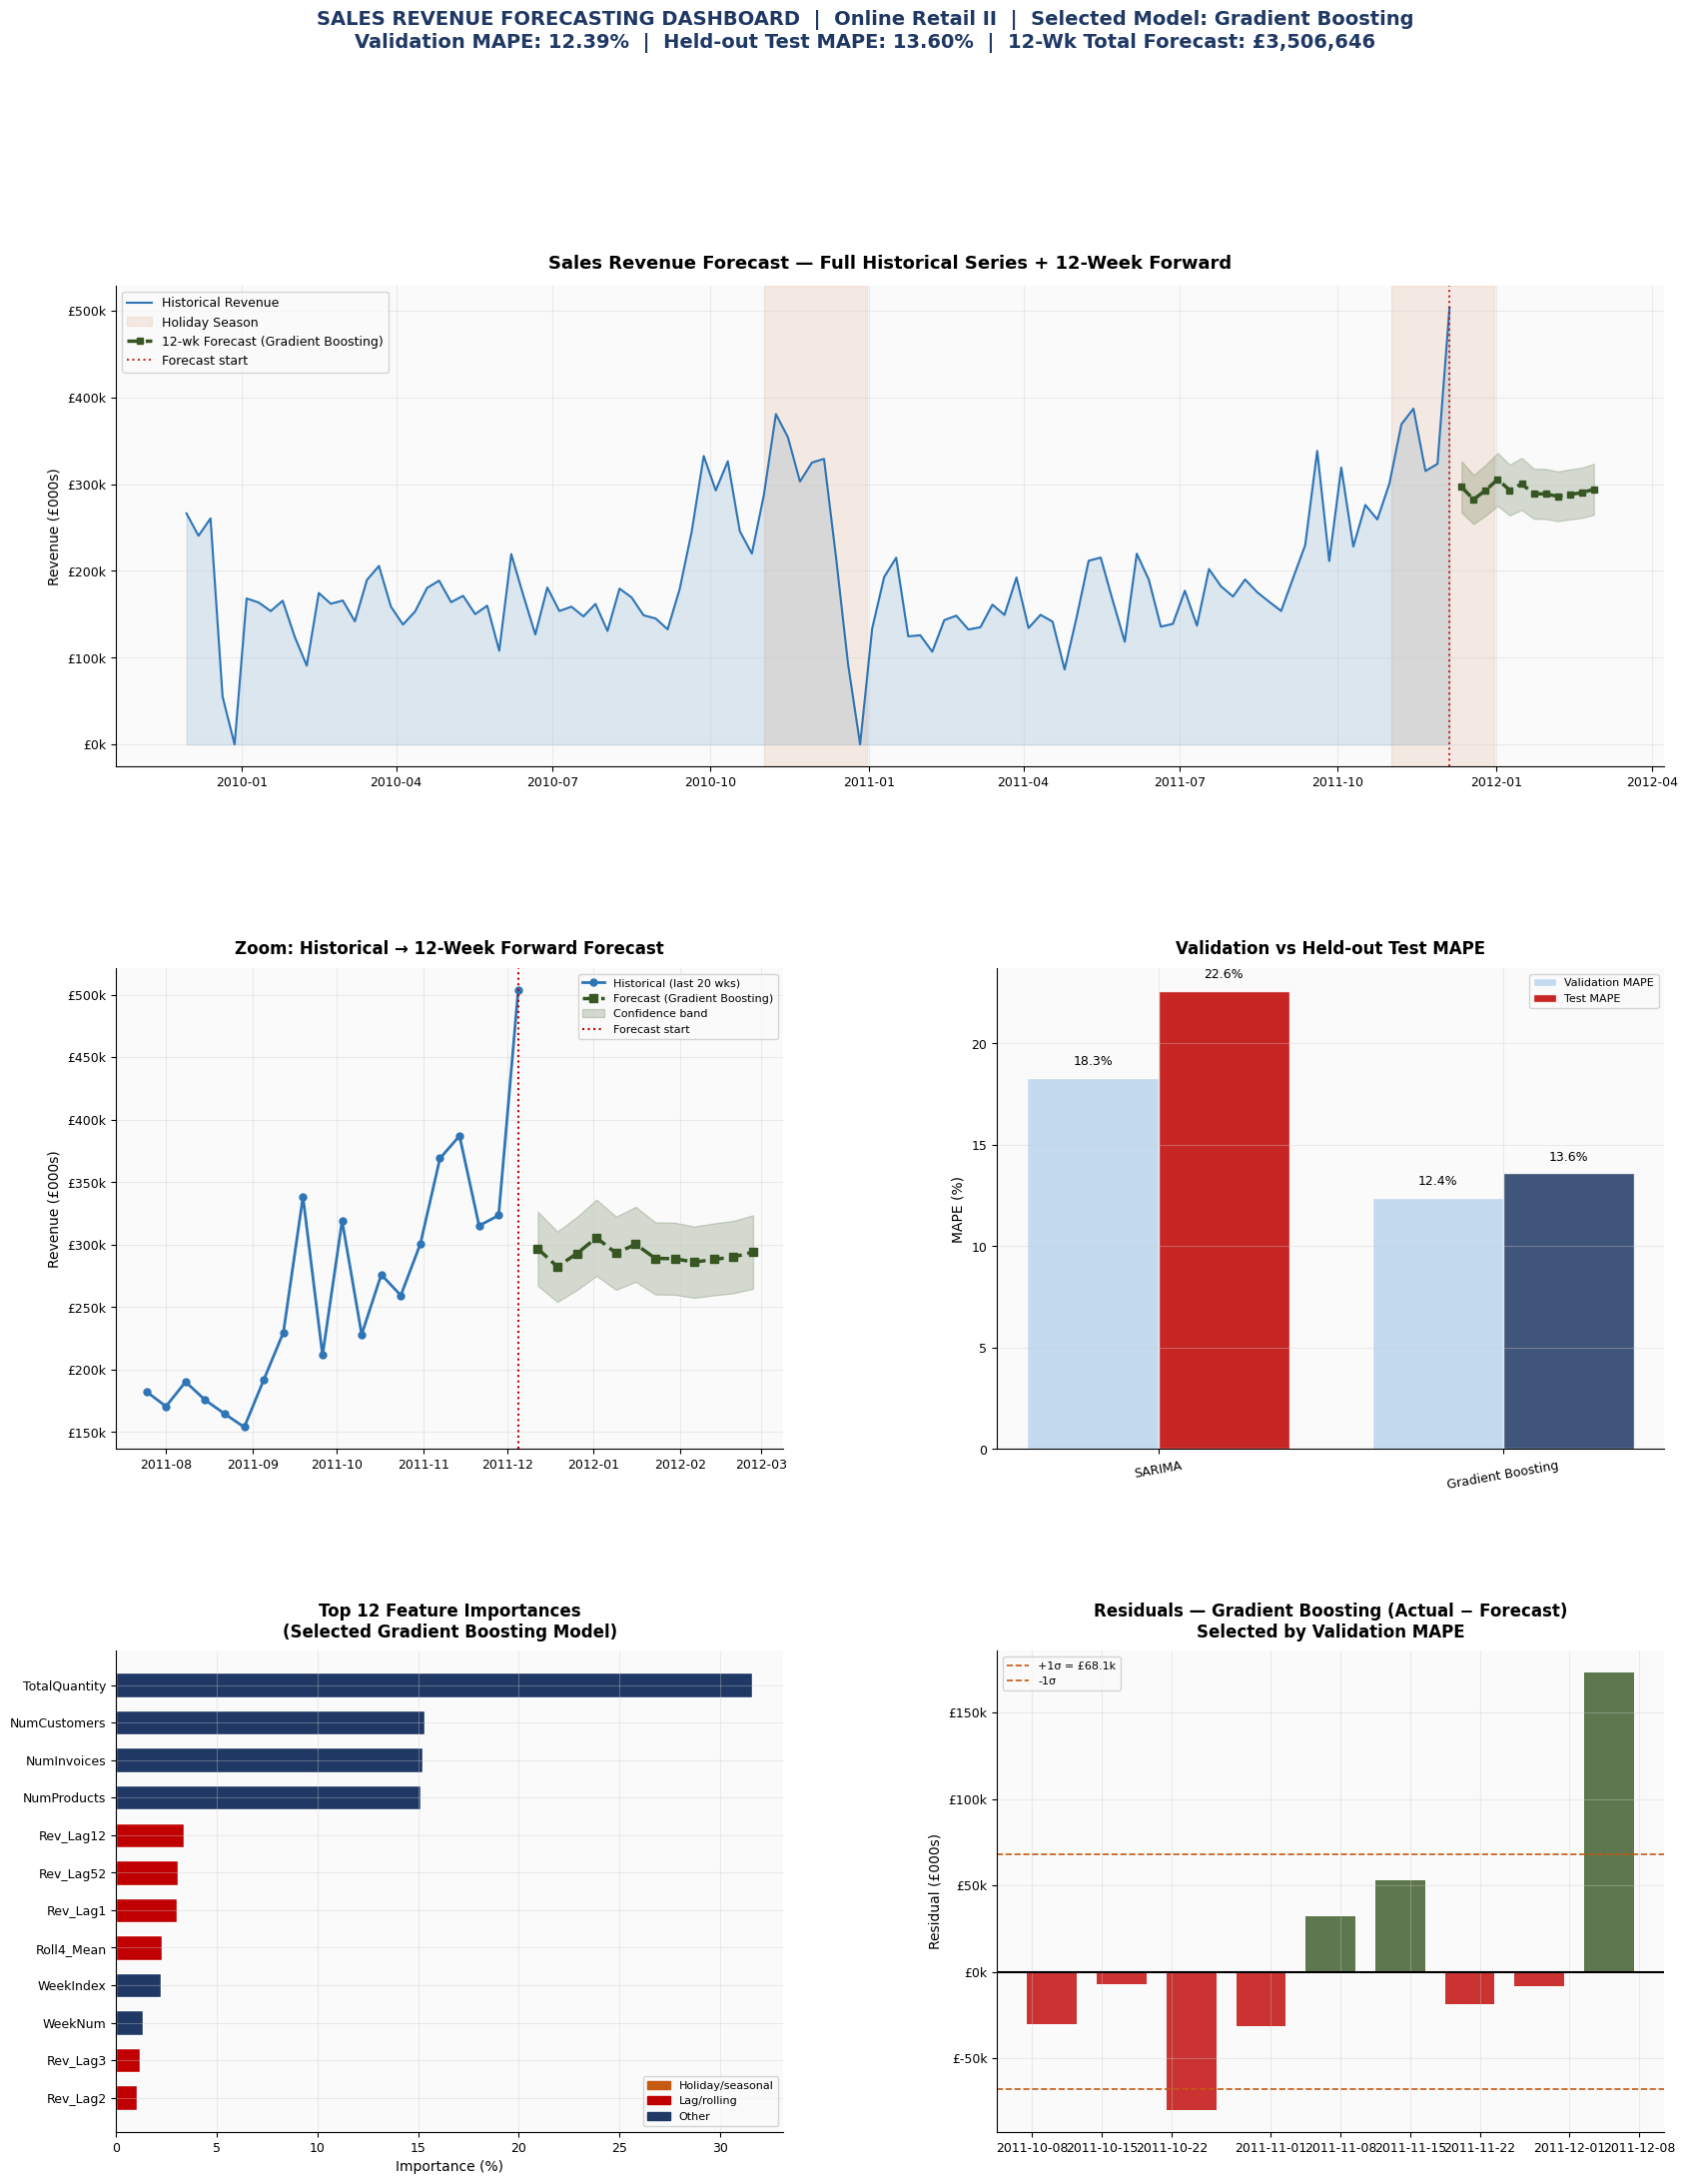


✅  Dashboard rendered.


In [16]:
fig = plt.figure(figsize=(20, 24))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(weekly['WeekStart'], weekly['TotalRevenue']/1000, alpha=0.15, color=C_BLUE)
ax1.plot(weekly['WeekStart'], weekly['TotalRevenue']/1000, color=C_BLUE, linewidth=1.5, label='Historical Revenue')
for yr in [2010, 2011]:
    ax1.axvspan(pd.Timestamp(f'{yr}-11-01'), pd.Timestamp(f'{yr}-12-31'), alpha=0.1, color=C_AMBER, label='Holiday Season' if yr == 2010 else '')
ax1.fill_between(future_dates, f_lower/1000, f_upper/1000, alpha=0.2, color=C_GREEN)
ax1.plot(future_dates, future_rev/1000, color=C_GREEN, linewidth=2.5, marker='s', markersize=5, linestyle='--', label=f'12-wk Forecast ({best_name})')
ax1.axvline(pd.Timestamp(weekly['WeekStart'].iloc[-1]), color=C_RED, linewidth=1.5, linestyle=':', alpha=0.8, label='Forecast start')
ax1.set_title("Sales Revenue Forecast — Full Historical Series + 12-Week Forward", fontsize=13, pad=12)
ax1.set_ylabel("Revenue (£000s)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax1.legend(loc='upper left', fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
hist_tail = 20
ht_dates = list(weekly['WeekStart'].values[-hist_tail:])
ht_vals = list(weekly['TotalRevenue'].values[-hist_tail:])
ax2.plot([pd.Timestamp(d) for d in ht_dates], np.array(ht_vals)/1000, color=C_BLUE, linewidth=2, marker='o', markersize=5, label='Historical (last 20 wks)')
ax2.plot(future_dates, future_rev/1000, color=C_GREEN, linewidth=2.5, marker='s', markersize=6, linestyle='--', label=f'Forecast ({best_name})')
ax2.fill_between(future_dates, f_lower/1000, f_upper/1000, alpha=0.2, color=C_GREEN, label='Confidence band')
ax2.axvline(pd.Timestamp(weekly['WeekStart'].iloc[-1]), color=C_RED, linewidth=1.5, linestyle=':', label='Forecast start')
ax2.set_title("Zoom: Historical → 12-Week Forward Forecast", fontsize=12, pad=10)
ax2.set_ylabel("Revenue (£000s)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
n_models = len(results)
x_pos = np.arange(n_models)
width = 0.38
val_bars = ax3.bar(x_pos - width/2, [results[name]['Validation_MAPE'] for name in names], width, color=C_LTBLUE, alpha=0.9, edgecolor='white', label='Validation MAPE')
test_bars = ax3.bar(x_pos + width/2, [results[name]['MAPE'] for name in names], width, color=[results[name]['color'] for name in names], alpha=0.85, edgecolor='white', label='Test MAPE')
ax3.set_title("Validation vs Held-out Test MAPE", fontsize=12, pad=10)
ax3.set_ylabel("MAPE (%)")
ax3.set_xticks(x_pos)
ax3.set_xticklabels(names, rotation=10, fontsize=9)
for bars in [val_bars, test_bars]:
    for bar in bars:
        value = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2, value + 0.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[2, 0])
top12 = feat_imp.head(12)
fi_colors = [C_AMBER if any(h in f for h in ['Holiday', 'Pre', 'Post', 'Summer']) else C_RED if any(h in f for h in ['Rev_Lag', 'Roll']) else C_NAVY for f in top12.index]
ax4.barh(top12.index[::-1], top12.values[::-1] * 100, color=fi_colors[::-1], edgecolor='white', height=0.65)
ax4.set_title("Top 12 Feature Importances\n(Selected Gradient Boosting Model)", fontsize=12, pad=10)
ax4.set_xlabel("Importance (%)")
handles4 = [
    mpatches.Patch(color=C_AMBER, label='Holiday/seasonal'),
    mpatches.Patch(color=C_RED, label='Lag/rolling'),
    mpatches.Patch(color=C_NAVY, label='Other'),
]
ax4.legend(handles=handles4, fontsize=8, loc='lower right')

ax5 = fig.add_subplot(gs[2, 1])
best_res = results[best_name]
residuals_best = best_res['actual'] - best_res['pred']
ax5.bar(best_res['dates'], residuals_best/1000, color=[C_GREEN if r > 0 else C_RED for r in residuals_best], alpha=0.8, width=5)
ax5.axhline(0, color='black', linewidth=1.5)
ax5.axhline(residuals_best.std()/1000, color=C_AMBER, linestyle='--', linewidth=1.2, label=f'+1σ = £{residuals_best.std()/1000:,.1f}k')
ax5.axhline(-residuals_best.std()/1000, color=C_AMBER, linestyle='--', linewidth=1.2, label='-1σ')
ax5.set_title(f"Residuals — {best_name} (Actual − Forecast)\nSelected by Validation MAPE", fontsize=12, pad=10)
ax5.set_ylabel("Residual (£000s)")
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}k'))
ax5.legend(fontsize=8)

fig.suptitle(
    f"SALES REVENUE FORECASTING DASHBOARD  |  Online Retail II  |  Selected Model: {best_name}\n"
    f"Validation MAPE: {results[best_name]['Validation_MAPE']:.2f}%  |  "
    f"Held-out Test MAPE: {results[best_name]['MAPE']:.2f}%  |  "
    f"12-Wk Total Forecast: £{sum(future_rev):,.0f}",
    fontsize=14,
    fontweight='bold',
    color=C_NAVY,
    y=0.995,
)
plt.show()
print("\n✅  Dashboard rendered.")


## CELL 15 — STEP 11: RESIDUAL DIAGNOSTICS DEEP DIVE

STEP 11 — RESIDUAL DIAGNOSTICS  

**Good forecasts have residuals that are:**

- ✔ Randomly distributed (no pattern) — model is unbiased
- ✔ Centred around zero               — well-calibrated
- ✔ Normally distributed              — errors are random
- ✔ No heteroscedasticity             — consistent error size

**Patterns indicate model improvement opportunities:**

Trend in residuals    → model misses long-term drift  
Seasonal pattern      → model misses seasonal component  
Growing variance      → model errors increase at high demand  


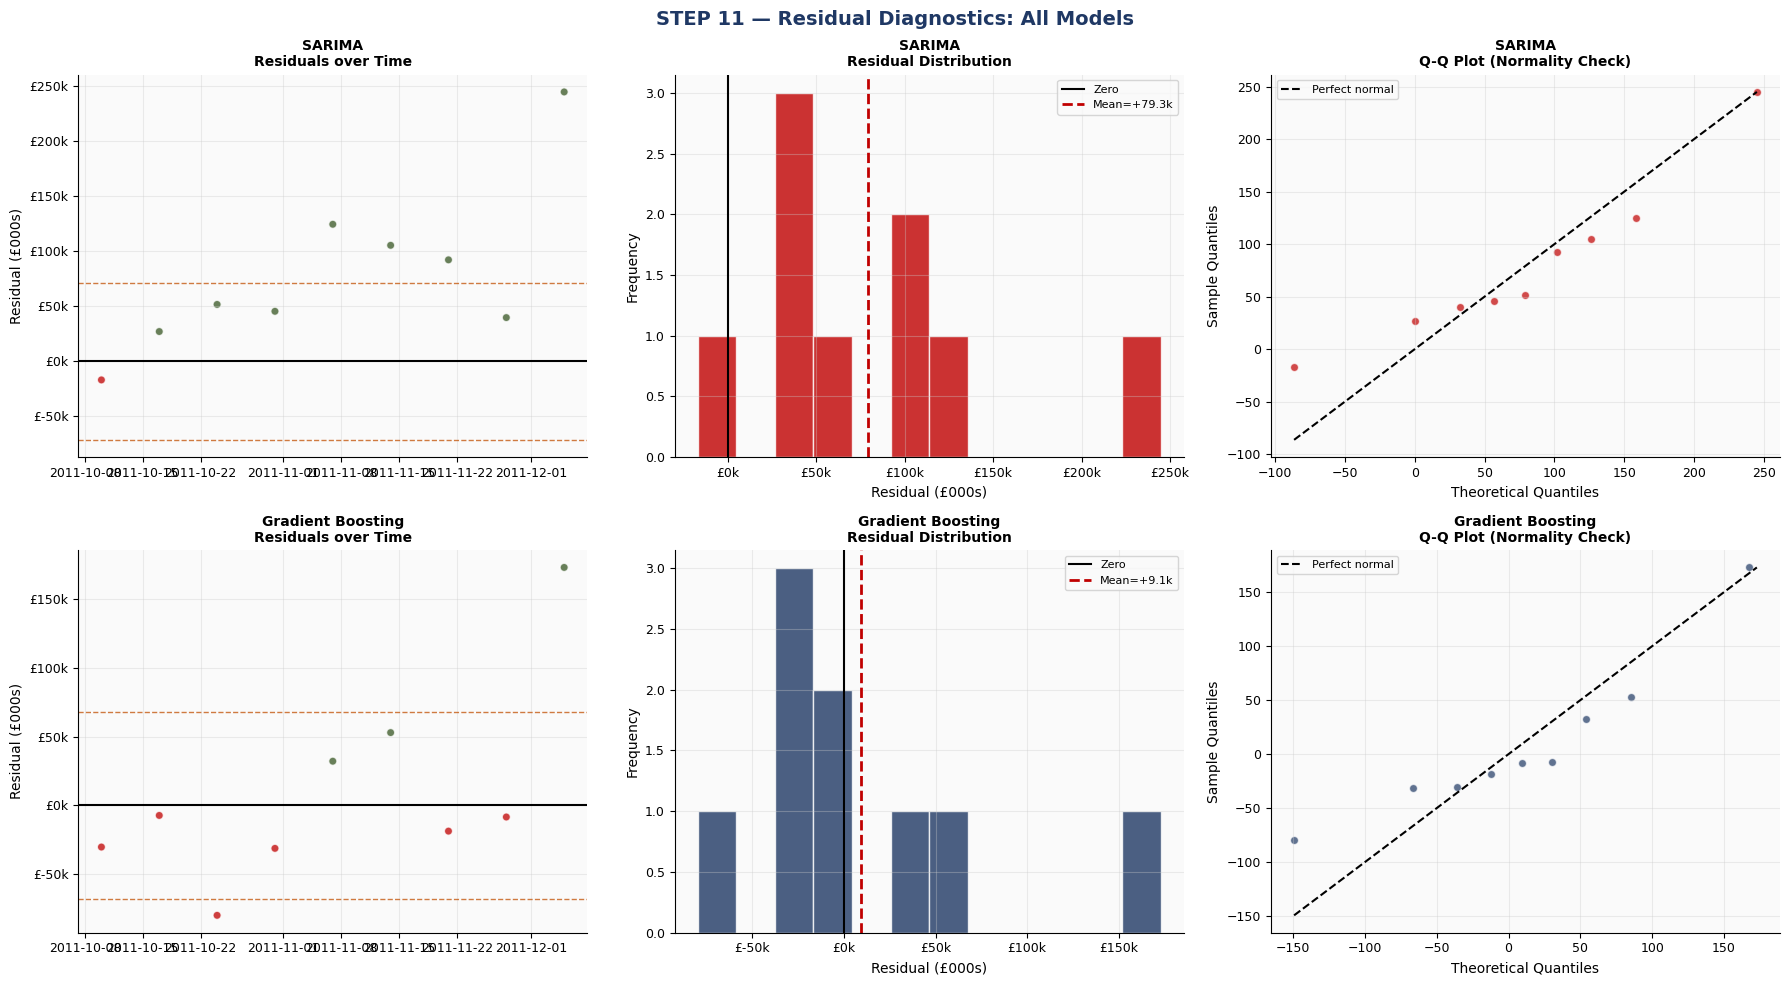


✅  Residual diagnostics complete.


In [17]:
n_models_plot = len(results)
fig, axes = plt.subplots(n_models_plot, 3, figsize=(18, 5*n_models_plot))
if n_models_plot == 1:
    axes = axes.reshape(1, -1)

for row, (name, r) in enumerate(results.items()):
    res = r['actual'] - r['pred']
    d_list = r['dates']

    ax_ts = axes[row, 0]
    ax_ts.scatter(d_list, res/1000, alpha=0.75,
                  color=[C_GREEN if x>0 else C_RED for x in res], s=35, edgecolors='white')
    ax_ts.axhline(0, color='black', linewidth=1.5)
    ax_ts.axhline( res.std()/1000, color=C_AMBER, linestyle='--', linewidth=1, alpha=0.8)
    ax_ts.axhline(-res.std()/1000, color=C_AMBER, linestyle='--', linewidth=1, alpha=0.8)
    ax_ts.set_title(f"{name}\nResiduals over Time", fontsize=10, fontweight='bold')
    ax_ts.set_ylabel("Residual (£000s)")
    ax_ts.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))

    ax_hist = axes[row, 1]
    ax_hist.hist(res/1000, bins=12, color=r['color'], alpha=0.8, edgecolor='white')
    ax_hist.axvline(0, color='black', linewidth=1.5, label='Zero')
    ax_hist.axvline(res.mean()/1000, color=C_RED, linewidth=2, linestyle='--',
                    label=f'Mean={res.mean()/1000:+.1f}k')
    ax_hist.set_title(f"{name}\nResidual Distribution", fontsize=10, fontweight='bold')
    ax_hist.set_xlabel("Residual (£000s)")
    ax_hist.set_ylabel("Frequency")
    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:,.0f}k'))
    ax_hist.legend(fontsize=8)

    ax_qq = axes[row, 2]
    sorted_res = np.sort(res/1000)
    theoretical = np.linspace(0.01, 0.99, len(sorted_res))
    from scipy import stats as sp_stats
    theoretical_q = sp_stats.norm.ppf(theoretical, loc=res.mean()/1000, scale=res.std()/1000)
    ax_qq.scatter(theoretical_q, sorted_res, alpha=0.7, color=r['color'], s=35, edgecolors='white')
    min_v = min(theoretical_q.min(), sorted_res.min())
    max_v = max(theoretical_q.max(), sorted_res.max())
    ax_qq.plot([min_v, max_v], [min_v, max_v], color='black', linewidth=1.5,
               linestyle='--', label='Perfect normal')
    ax_qq.set_title(f"{name}\nQ-Q Plot (Normality Check)", fontsize=10, fontweight='bold')
    ax_qq.set_xlabel("Theoretical Quantiles")
    ax_qq.set_ylabel("Sample Quantiles")
    ax_qq.legend(fontsize=8)

plt.suptitle("STEP 11 — Residual Diagnostics: All Models",
             fontsize=14, fontweight='bold', color=C_NAVY)
plt.tight_layout()
plt.show()
print("\n✅  Residual diagnostics complete.")


## CELL 16 — STEP 12: ALGORITHM COMPARISON TABLE

STEP 12 — ALGORITHM COMPARISON TABLE


In [18]:
print("=" * 65)
print("  STEP 12 — ALGORITHM COMPARISON")
print("=" * 65)

comparison_data = []
for name, r in results.items():
    comparison_data.append({
        'Model': name,
        'Validation MAPE (%)': f"{r['Validation_MAPE']:.2f}%",
        'Test MAPE (%)': f"{r['MAPE']:.2f}%",
        'Test MAE (£)': f"£{r['MAE']:,.0f}",
    })

compare_df = pd.DataFrame(comparison_data)
compare_df['Selected?'] = compare_df['Model'].apply(lambda x: '★ YES (lowest val MAPE)' if x == best_name else 'No')

print(f"\n  {'Model':<22} {'Val MAPE':<16} {'Test MAPE':<16} {'Test MAE (£)':<14} {'Selected?'}")
print("  " + "-" * 92)
for _, row in compare_df.iterrows():
    print(f"  {row['Model']:<22} {row['Validation MAPE (%)']:<16} {row['Test MAPE (%)']:<16} {row['Test MAE (£)']:<14} {row['Selected?']}")

pros_cons = {
    'SARIMA': {
        'Pros': 'Interpretable statistical baseline; native interval forecasts; handles autocorrelation well',
        'Cons': 'Less flexible on abrupt non-linear shifts; seasonal tuning can be slow',
        'Best for': 'Stable seasonal demand with strong auditability needs',
    },
    'Prophet': {
        'Pros': 'Holiday-aware; decomposes trend and seasonality cleanly; robust to changepoints',
        'Cons': 'Requires Prophet installation; less transparent than classical regression',
        'Best for': 'Business time series with holiday/event effects',
    },
    'Gradient Boosting': {
        'Pros': 'Captures non-linear patterns; uses rich lag features; strong retail forecasting baseline',
        'Cons': 'Needs feature engineering; forward forecast depends on rolling lag assumptions',
        'Best for': 'Volatile retail demand with multiple interacting drivers',
    },
}

print(f"\n  Pros / Cons Summary:")
print("  " + "-" * 88)
for model, pc in pros_cons.items():
    if model in results:
        print(f"\n  {model}:")
        print(f"    Pros     : {pc['Pros']}")
        print(f"    Cons     : {pc['Cons']}")
        print(f"    Best for : {pc['Best for']}")

print("\n Reporting note: MAPE is reported on a 0-100 scale. Model selection is based on validation MAPE; test MAPE is held out for final reporting.")
print("\n✅  Algorithm comparison complete.")


  STEP 12 — ALGORITHM COMPARISON

  Model                  Val MAPE         Test MAPE        Test MAE (£)   Selected?
  --------------------------------------------------------------------------------------------
  SARIMA                 18.28%           22.58%           £83,019        No
  Gradient Boosting      12.39%           13.60%           £48,197        ★ YES (lowest val MAPE)

  Pros / Cons Summary:
  ----------------------------------------------------------------------------------------

  SARIMA:
    Pros     : Interpretable statistical baseline; native interval forecasts; handles autocorrelation well
    Cons     : Less flexible on abrupt non-linear shifts; seasonal tuning can be slow
    Best for : Stable seasonal demand with strong auditability needs

  Gradient Boosting:
    Pros     : Captures non-linear patterns; uses rich lag features; strong retail forecasting baseline
    Cons     : Needs feature engineering; forward forecast depends on rolling lag assumptions
    

## CELL 17 — STEP 13: SAVE ALL RESULTS TO CSV

STEP 13 — EXPORT DELIVERABLES

**CSV deliverables produced by this notebook:**

1. `future_revenue_forecast_12weeks.csv` — 12-week operational forecast
2. `test_period_predictions.csv` — held-out test predictions for each model
3. `model_comparison_metrics.csv` — validation MAPE, test MAPE, and test MAE
4. `test_period_mape_summary.csv` — equal-period MAPE breakdown for the selected model
5. `weekly_revenue_features.csv` — modeling dataset with engineered features


In [19]:
print("=" * 65)
print("  STEP 13 — EXPORTING RESULTS")
print("=" * 65)

forecast_df.to_csv('future_revenue_forecast_12weeks.csv', index=False)

test_pred_rows = []
for name, r in results.items():
    ape = np.where(
        np.asarray(r['actual']) != 0,
        np.abs((np.asarray(r['actual']) - np.asarray(r['pred'])) / np.asarray(r['actual'])) * 100,
        np.nan,
    )
    for d, a, p, ape_i in zip(r['dates'], r['actual'], r['pred'], ape):
        test_pred_rows.append({
            'WeekStart': str(pd.Timestamp(d).date()),
            'Model': name,
            'Actual_Revenue': round(float(a), 2),
            'Forecast_Revenue': round(float(p), 2),
            'Residual': round(float(a - p), 2),
            'Absolute_Percentage_Error_%': round(float(ape_i), 4) if not np.isnan(ape_i) else np.nan,
            'Selected_Model': name == best_name,
        })
test_pred_df = pd.DataFrame(test_pred_rows)
test_pred_df.to_csv('test_period_predictions.csv', index=False)

metrics_out = []
for name, r in results.items():
    metrics_out.append({
        'Model': name,
        'Validation_MAPE_%': round(float(r['Validation_MAPE']), 4),
        'Test_MAPE_%': round(float(r['MAPE']), 4),
        'Test_MAE_GBP': round(float(r['MAE']), 2),
        'Selected_Model': name == best_name,
    })
metrics_df = pd.DataFrame(metrics_out)
metrics_df.to_csv('model_comparison_metrics.csv', index=False)

period_summary_df.to_csv('test_period_mape_summary.csv', index=False)
wdf.to_csv('weekly_revenue_features.csv', index=False)

print(f"\n  Files saved:")
print(f"    future_revenue_forecast_12weeks.csv  ({len(forecast_df)} rows)")
print(f"    test_period_predictions.csv          ({len(test_pred_df)} rows)")
print(f"    model_comparison_metrics.csv         ({len(metrics_df)} rows)")
print(f"    test_period_mape_summary.csv         ({len(period_summary_df)} rows)")
print(f"    weekly_revenue_features.csv          ({len(wdf)} rows)")

print(f"\n  To download in Colab:")
print(f"    from google.colab import files")
print(f"    files.download('future_revenue_forecast_12weeks.csv')")
print()
print(f"\n{'=' * 65}")
print(f"  PIPELINE COMPLETE — EXECUTIVE SUMMARY")
print(f"{'=' * 65}")
print(f'''
  Dataset      : Online Retail II  ({len(df):,} clean records)
  Target       : Weekly Sales Revenue (£)
  Models run   : {' | '.join(results.keys())}
  Selected     : {best_name}

  ┌──────────────────────────────┬────────────┐
  │ Metric                       │ Value      │
  ├──────────────────────────────┼────────────┤
  │ Validation MAPE              │ {results[best_name]['Validation_MAPE']:>8.2f}% │
  │ Held-out Test MAPE           │ {results[best_name]['MAPE']:>8.2f}% │
  │ Held-out Test MAE            │ £{results[best_name]['MAE']:>9,.0f} │
  │ 12-wk Total Forecast         │ £{sum(future_rev)/1000:>7,.1f}k │
  └──────────────────────────────┴────────────┘

  Deliverables:
    future_revenue_forecast_12weeks.csv
    test_period_predictions.csv
    model_comparison_metrics.csv
    test_period_mape_summary.csv
    weekly_revenue_features.csv
''')
metrics_df


  STEP 13 — EXPORTING RESULTS

  Files saved:
    future_revenue_forecast_12weeks.csv  (12 rows)
    test_period_predictions.csv          (18 rows)
    model_comparison_metrics.csv         (2 rows)
    test_period_mape_summary.csv         (3 rows)
    weekly_revenue_features.csv          (54 rows)

  To download in Colab:
    from google.colab import files
    files.download('future_revenue_forecast_12weeks.csv')


  PIPELINE COMPLETE — EXECUTIVE SUMMARY

  Dataset      : Online Retail II  (1,007,956 clean records)
  Target       : Weekly Sales Revenue (£)
  Models run   : SARIMA | Gradient Boosting
  Selected     : Gradient Boosting

  ┌──────────────────────────────┬────────────┐
  │ Metric                       │ Value      │
  ├──────────────────────────────┼────────────┤
  │ Validation MAPE              │    12.39% │
  │ Held-out Test MAPE           │    13.60% │
  │ Held-out Test MAE            │ £   48,197 │
  │ 12-wk Total Forecast         │ £3,506.6k │
  └─────────────────────

,Model,Validation_MAPE_%,Test_MAPE_%,Test_MAE_GBP,Selected_Model
0,SARIMA,18.28,22.58,"83,018.96",False
1,Gradient Boosting,12.39,13.60,"48,197.09",True
